Demo parsing Snippets for local use.

Due to the size and availability of .dem files. Providing code that performs our analysis from the point of getting the .dems is expensive. As a result below is some generalized code that can be used to parse demos for our purposes, given you garner the .dem files from the sources we provide.

In [ ]:
from os import listdir
from os.path import isfile, join
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import glob
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
from math import pi
import os
import requests
pd.set_option('display.max_columns', None)
plt.style.use('dark_background')
!pip install awpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 12.6 MB/s eta 0:00:00
  Attempting uninstall: polars
    Found existing installation: polars 1.21.0
    Uninstalling polars-1.21.0:
      Successfully uninstalled polars-1.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-polars-cu12 25.2.2 requires polars<1.22,>=1.20, but you have polars 1.30.0 which is incompatible.


In [ ]:
import os
from awpy import Demo
import polars as pl


#set up folders for your use
demos_folder = "folder_of_demos"
output_folder = "output_folder_for_parsed_demos"
os.makedirs(output_folder, exist_ok=True)

#dataframes we gathered for our analyis. Change this to contain as many or as few data frames as you'd like.
dataframes_to_save = ["rounds", "grenades", "kills", "damages", "bomb", "smokes", "infernos", "shots"]

def parse_demos(in_folder, out_folder, verbose=True):

    files = [f for f in os.listdir(in_folder) if f.endswith(".dem")] #look for demo files in folder

    for f in files:
        path = os.path.join(in_folder, f)
        if verbose:
            print(f"Parsing {f}")
        try:
            demo = Demo(path, verbose=verbose) #create a demo object from demo file
            demo.parse() #parse demo to get dataframes as attributes
            name = os.path.splitext(f)[0]

            for df_name in dataframes_to_save:
                df = getattr(demo, df_name, None) #for each dataframe name, get that from the parsed demo and save it as a csv
                if isinstance(df, pl.DataFrame) and df.height > 0:
                    out_path = os.path.join(out_folder, f"{name}_{df_name}.csv")
                    df.write_csv(out_path)
                    if verbose:
                        print(f"Saved: {out_path}")
        except Exception as e:
            print(f"Problem with {f}: {e}")
            #you'll notice some attributes (sounds often) are broken
            #demos are often corrupted for one reason or another
            #if a dataframe is empty, you unfortunately can't use it

def filter_by_tick(folder, keyword, every_n, verbose=True):

  for f in os.listdir(folder):
      if keyword in f and f.endswith(".csv"):
          path = os.path.join(folder, f)
          if verbose:
              print(f"Filtering {f}")
          df = pl.read_csv(path)
          if "tick" in df.columns:
              df = df.filter(pl.col("tick") % every_n == 0)
              df.write_csv(path)
              if verbose:
                  print(f"Saved filtered: {f}")
          else:
              if verbose:
                  print(f"No 'tick' column in {f}, skipped")


#Example usage:
#parse_demos(demos_folder, output_folder, verbose=True)
#filter_by_tick(output_folder, "grenades", 8, verbose=True)

The github we link to below has done this for every match at IEM Dallas 2025 that was played by either Vitality or Mouz
Rank 1 and Rank 2, Winner and Runner Up respectively.

In [ ]:
# for a given repo containing CSVs, this function downloads all to our google collab space.

def download_csvs(user, repo, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    tree_url = f"https://api.github.com/repos/{user}/{repo}/git/trees/main?recursive=1"
    raw_base = f"https://raw.githubusercontent.com/{user}/{repo}/main/"

    r = requests.get(tree_url)
    csv_files = [f["path"] for f in r.json()["tree"] if f["path"].endswith(".csv")]

    for file in csv_files:
        url = raw_base + file
        dest = os.path.join(output_folder, os.path.basename(file))

        file_data = requests.get(url)
        if file_data.ok:
            with open(dest, "wb") as f:
                f.write(file_data.content)
            print(f"Downloaded: {file}")
        else:
            print(f"Failed: {file}")

In [ ]:
download_csvs("tahaz", "iemDallasMouzAndVitDems", "/content/DLfromGitHubTesting")

Downloaded: maps_statistics.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_bomb.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_damages.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_grenades.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_infernos.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_kills.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_rounds.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_shots.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m1-mirage_smokes.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_bomb.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_damages.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_grenades.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_infernos.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_kills.csv
Downloaded: parsed_demos/gamerlegion-vs-vitality-m2-nuke_rounds.c

Function to put parsed demo files into dataframes

In [ ]:
def get_df(team_name, file_type, file_path = "/content/DLfromGitHubTesting/", roster = []):
  proper_file_types = ["bomb", "damages", "grenades", "infernos", "kills", "rounds", "shots", "smokes"]

  if file_type not in proper_file_types:
    return f"Invalid file type please use from {proper_file_types}"

  #just get match files which include "vs"
  files = [f for f in listdir(file_path) if isfile(join(file_path, f)) and "vs" in f]

  #filter down to files that have
  team_files = [f for f in files if team_name in f and file_type in f]

  list_df = []

  for filename in team_files:
    full_path = file_path + filename

    team1, rest = filename.split("-vs-",1)
    team2 = rest.split("-")[0]
    team1 = team1.strip().lower()
    team2 = team2.strip().lower()

    if team2 =="the":
      team2 = "mongolz"

    #get map name
    map_parts = rest.split("-")
    for part in map_parts:
        if part in ['m1', 'm2', 'm3']:  # match indicators
            map_played = map_parts[map_parts.index(part) + 1].split("_")[0]
            break


    df = pd.read_csv(full_path)
    df["map"] = map_played

    df["opponent"] = team2 if team1 == team_name else team1
    list_df.append(df)

  #combine list of df into one large df
  combined_df = pd.concat(list_df, axis = 0)

  #filter for players in roster
  if len(roster) >= 1:
    if file_type == "kills" or file_type == "damages":
      combined_df = combined_df[combined_df["attacker_name"].isin(roster)]
    elif file_type == "grenades":
      combined_df = combined_df[combined_df["thrower"].isin(roster)]
    elif file_type == "infernos":
      combined_df = combined_df[combined_df["thrower_name"].isin(roster)]

  #drop steamid
  steam_id_col = [col for col in combined_df.columns if "steamid" in col]
  combined_df = combined_df.drop(columns = steam_id_col, axis = 1)

  return combined_df



In [ ]:
mouz_roster = ["Brollan", "torzsi", "Spinx", "Jimpphat", "xertioN"]
vitality_roster = ["apEX", "ropz", "ZywOo", "flameZ", "mezii"]

In [ ]:
df_kills_vitality = get_df("vitality", "kills", roster = vitality_roster)
df_rounds_vitality = get_df("vitality", "rounds", roster = vitality_roster)
df_damages_vitality = get_df("vitality", "damages", roster = vitality_roster)

df_kills_mouz = get_df("mouz", "kills", roster = mouz_roster)
df_rounds_mouz = get_df("mouz", "rounds", roster = mouz_roster)
df_damages_mouz = get_df("mouz", "damages", roster = mouz_roster)

Player performace matrix. This calculates each player's overall weapon skills. This will be later used for correlation matrix.

In [ ]:
# player proformance matrix, we can add or subtract from this at will
def create_player_performance_df(df_kills, team_name):
    player_stats = df_kills.groupby('attacker_name').agg({'headshot': ['sum', 'mean'], 'distance': ['mean', 'std'], 'victim_name': 'count',}).round(3)

    player_stats.columns = ['total_headshots', 'headshot_rate', 'total_kills', 'avg_distance', 'distance_std']

    player_stats['hs_percentage'] = (player_stats['total_headshots'] / player_stats['total_kills'] * 100).round(2)

    rifle_weapons = ['ak47', 'm4a4', 'm4a1_silencer', 'ssg08', 'aug', 'famas', 'galilar', 'sg556', 'awp', 'g3sg1', 'scar20']
    rifle_stats = df_kills[df_kills['weapon'].isin(rifle_weapons)].groupby('attacker_name').agg({'headshot': 'mean', 'distance': 'mean', 'victim_name': 'count'}).round(3)
    rifle_stats.columns = ['rifle_hs_rate', 'rifle_avg_distance', 'rifle_kills']

    pistols_weapons = ['usp_silencer', 'glock', 'deagle', 'hkp2000', 'elite', 'p250', 'tec9', 'fiveseven', 'cz75a', 'revolver']
    pistols_stats = df_kills[df_kills['weapon'].isin(pistols_weapons)].groupby('attacker_name').agg({'headshot': 'mean', 'distance': 'mean', 'victim_name': 'count'}).round(3)
    pistols_stats.columns = ['pistols_hs_rate', 'pistols_avg_distance', 'pistols_kills']

    #kills consistency is std hs% per map per player
    map_performance = df_kills.groupby(['attacker_name', 'map']).agg({'victim_name': 'count', 'headshot': 'mean'}).groupby('attacker_name').agg({'victim_name': ['mean', 'std'],'headshot': 'mean'}).round(3)
    map_performance.columns = ['avg_kills_per_map', 'std_of_kills_across_maps', 'avg_hs_rate_maps']
    std_min = map_performance['std_of_kills_across_maps'].min()
    std_max = map_performance['std_of_kills_across_maps'].max()
    map_performance['normalized_consistency_score'] = ((std_max - map_performance['std_of_kills_across_maps']) / (std_max - std_min)).round(3)
    #std_of_kills_across_maps: higher is better

    combined_stats = player_stats.join(rifle_stats, how='left').join(pistols_stats, how='left').join(map_performance, how='left')
    combined_stats['team'] = team_name

    combined_stats = combined_stats.fillna(0)

    return combined_stats.reset_index()

vitality_performance = create_player_performance_df(df_kills_vitality, 'Vitality')
mouz_performance = create_player_performance_df(df_kills_mouz, 'MOUZ')
all_players_performance = pd.concat([vitality_performance, mouz_performance], ignore_index=True)
print(all_players_performance.head(10))

  attacker_name  total_headshots  headshot_rate  total_kills  avg_distance  \
0         ZywOo              105          0.463       22.636        12.659   
1          apEX               85          0.480       18.003         9.676   
2        flameZ               97          0.505       17.452         9.969   
3         mezii              106          0.546       18.411        10.007   
4          ropz              112          0.574       17.141         9.640   
5       Brollan               65          0.468       16.817         8.972   
6      Jimpphat               80          0.519       19.030        10.298   
7         Spinx              113          0.562       19.537         9.399   
8        torzsi               57          0.294       23.195        12.017   
9       xertioN               81          0.506       18.564         9.560   

   distance_std  hs_percentage  rifle_hs_rate  rifle_avg_distance  \
0           227         463.86          0.391              24.454   
1  

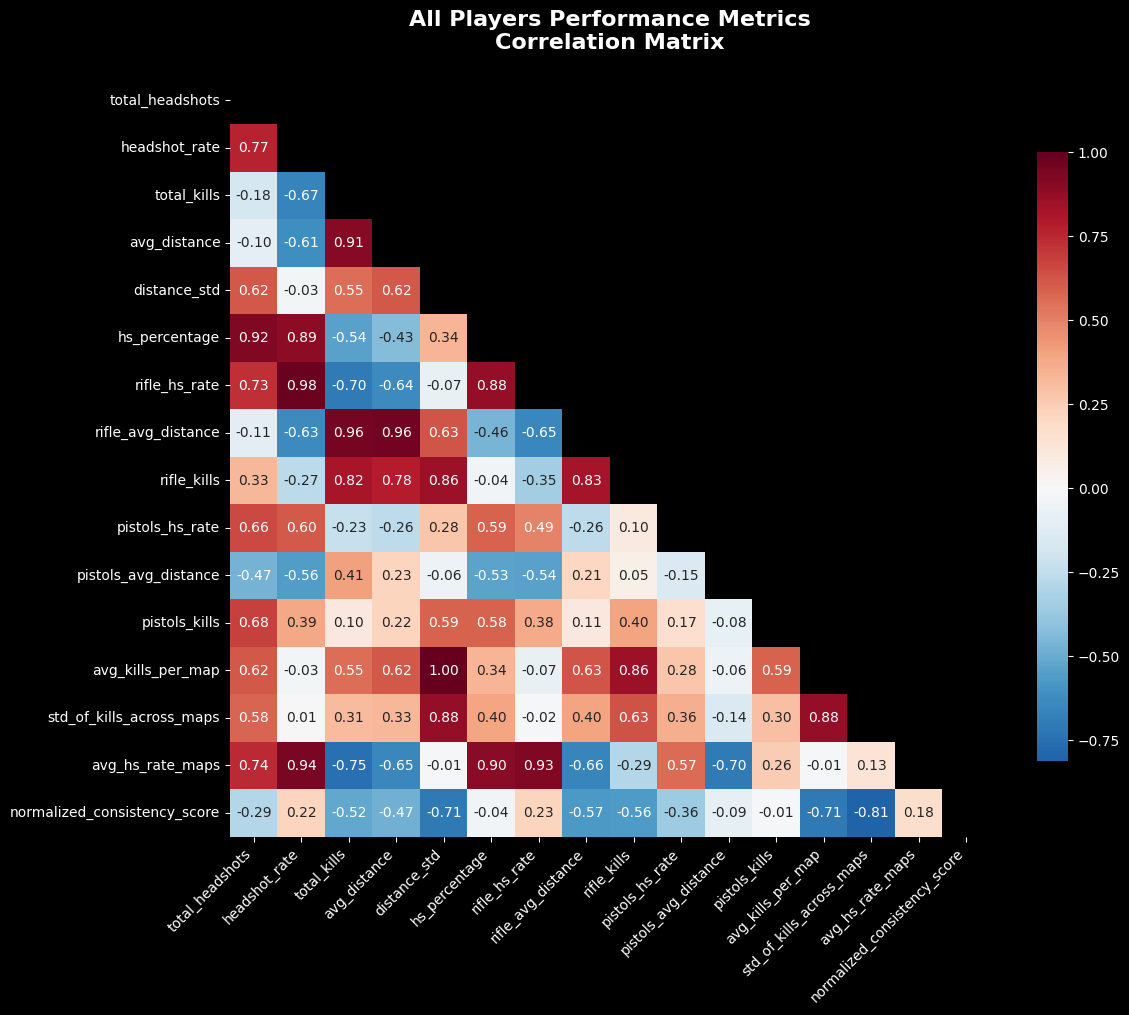

In [ ]:
#correlation heatmap
def plot_correlation_heatmap(df, title, figsize=(12, 10)):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=figsize)

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8}, ax=ax)
    plt.title(f'{title}\nCorrelation Matrix', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    return fig

fig1 = plot_correlation_heatmap(all_players_performance, 'All Players Performance Metrics')
plt.show()

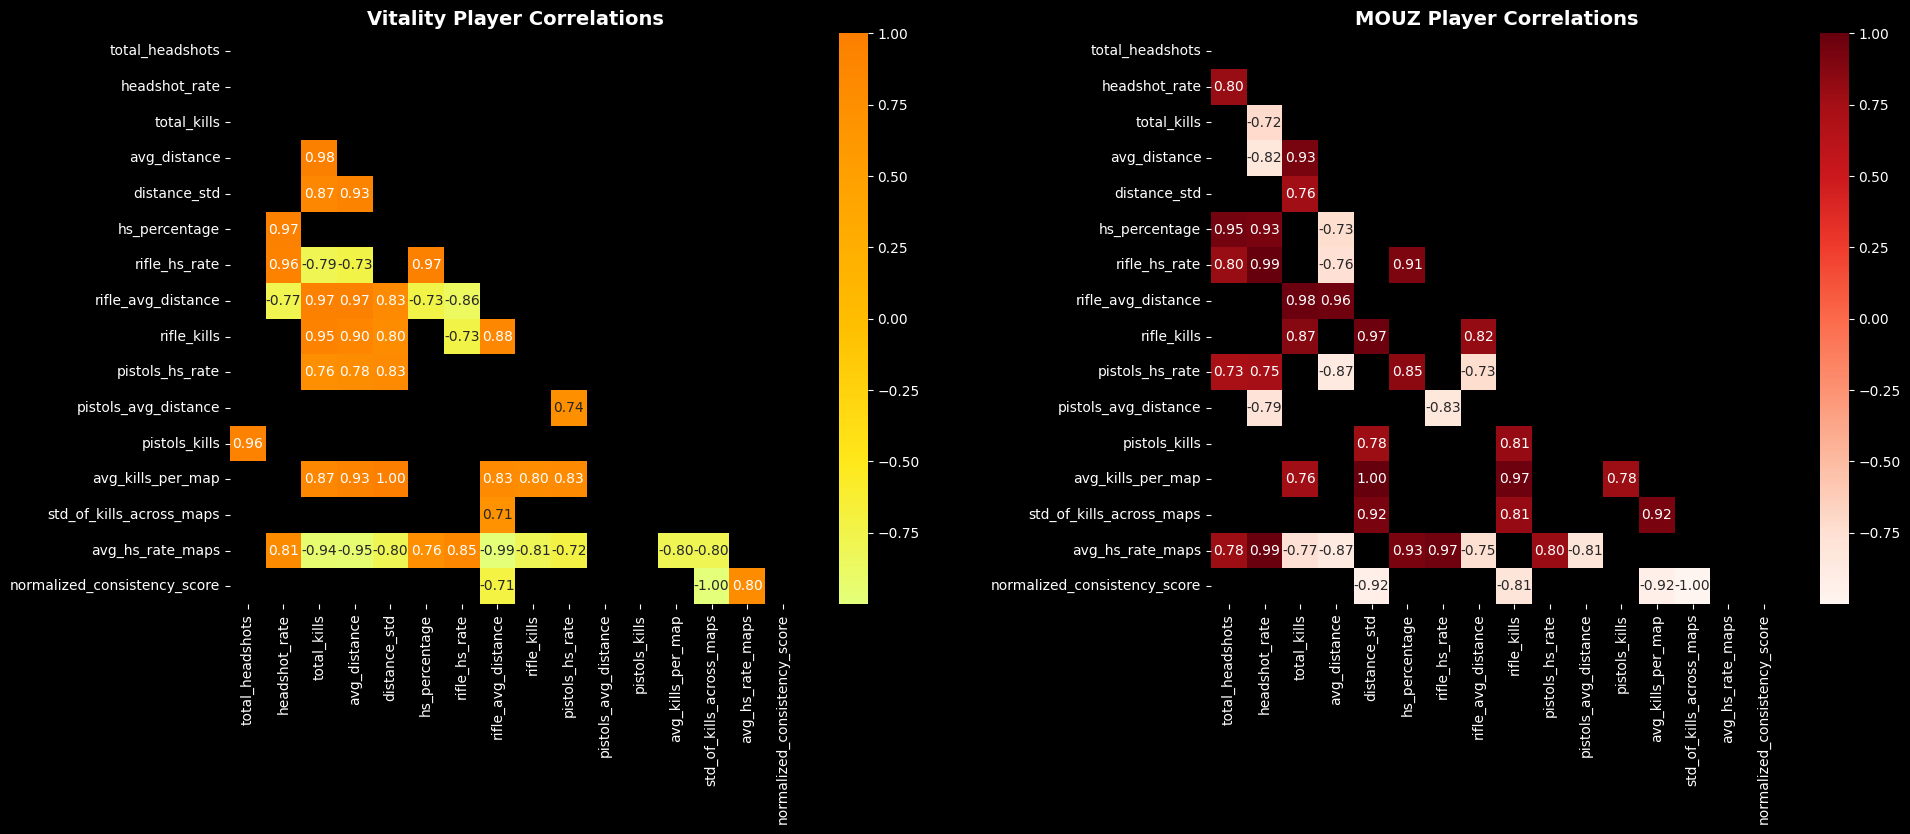

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Vitality correlation
vitality_numeric = vitality_performance.select_dtypes(include=[np.number])
vitality_corr = vitality_numeric.corr()
mask1 = np.triu(np.ones_like(vitality_corr, dtype=bool)) | (vitality_corr.abs() < 0.7)
sns.heatmap(vitality_corr, mask=mask1, annot=True, cmap='Wistia', center=0, square=True, fmt='.2f', ax=axes[0])
axes[0].set_title('Vitality Player Correlations', fontsize=14, fontweight='bold')

# MOUZ correlation
mouz_numeric = mouz_performance.select_dtypes(include=[np.number])
mouz_corr = mouz_numeric.corr()
mask2 = np.triu(np.ones_like(mouz_corr, dtype=bool))| (mouz_corr.abs() < 0.7)
sns.heatmap(mouz_corr, mask=mask2, annot=True, cmap='Reds', center=0, square=True, fmt='.2f', ax=axes[1])
axes[1].set_title('MOUZ Player Correlations', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Create weapon usage rate and its performace across maps played. This helps us see how each weapons were used and if each weapon performed better or worse depending on the map.

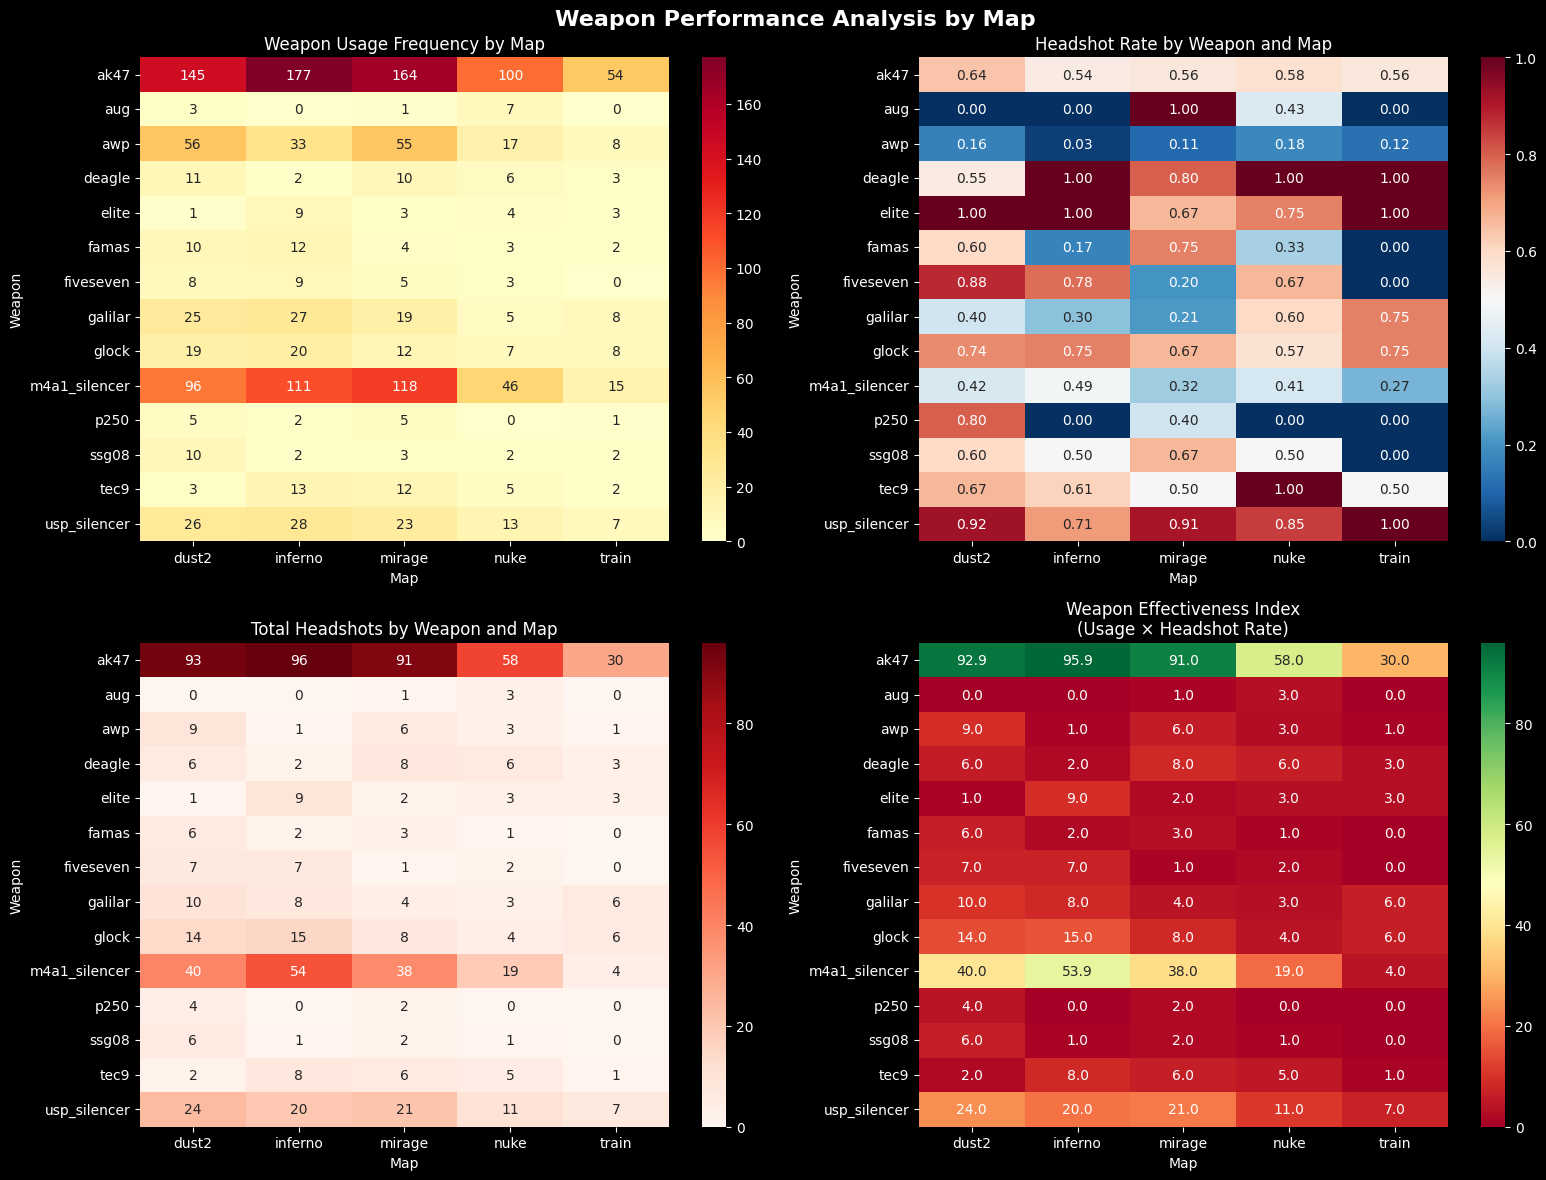

In [ ]:
def analyze_weapon_map_performance():
    all_kills = pd.concat([df_kills_vitality, df_kills_mouz], ignore_index=True)

    main_weapons = ['ak47', 'm4a4', 'm4a1_silencer', 'ssg08', 'aug', 'famas', 'galilar', 'sg556', 'awp', 'g3sg1',
                    'scar20', 'usp_silencer', 'glock', 'deagle', 'hkp2000', 'elite', 'p250', 'tec9', 'fiveseven', 'cz75a', 'revolver']
    weapon_map_data = all_kills[all_kills['weapon'].isin(main_weapons)]

    weapon_map_stats = weapon_map_data.groupby(['map', 'weapon']).agg({
        'headshot': ['sum', 'mean'],
        'victim_name': 'count'
    }).round(3)

    weapon_map_stats.columns = ['total_headshots', 'hs_rate', 'usage_count']
    weapon_map_stats = weapon_map_stats.reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Weapon Performance Analysis by Map', fontsize=16, fontweight='bold')

    weapon_usage = weapon_map_stats.pivot_table(
        index='weapon', columns='map', values='usage_count', fill_value=0
    )

    sns.heatmap(weapon_usage, annot=True, cmap='YlOrRd', fmt='.0f', ax=axes[0,0])
    axes[0,0].set_title('Weapon Usage Frequency by Map')
    axes[0,0].set_xlabel('Map')
    axes[0,0].set_ylabel('Weapon')

    weapon_hs = weapon_map_stats.pivot_table(
        index='weapon', columns='map', values='hs_rate', fill_value=0
    )

    sns.heatmap(weapon_hs, annot=True, cmap='RdBu_r', fmt='.2f', ax=axes[0,1])
    axes[0,1].set_title('Headshot Rate by Weapon and Map')
    axes[0,1].set_xlabel('Map')
    axes[0,1].set_ylabel('Weapon')

    weapon_total_hs = weapon_map_stats.pivot_table(
        index='weapon', columns='map', values='total_headshots', fill_value=0
    )

    sns.heatmap(weapon_total_hs, annot=True, cmap='Reds', fmt='.0f', ax=axes[1,0])
    axes[1,0].set_title('Total Headshots by Weapon and Map')
    axes[1,0].set_xlabel('Map')
    axes[1,0].set_ylabel('Weapon')

    weapon_effectiveness = weapon_usage * weapon_hs
    weapon_effectiveness = weapon_effectiveness.fillna(0)

    sns.heatmap(weapon_effectiveness, annot=True, cmap='RdYlGn', fmt='.1f', ax=axes[1,1])
    axes[1,1].set_title('Weapon Effectiveness Index\n(Usage × Headshot Rate)')
    axes[1,1].set_xlabel('Map')
    axes[1,1].set_ylabel('Weapon')

    plt.tight_layout()
    return fig, weapon_map_stats

weapon_analysis_fig, weapon_stats = analyze_weapon_map_performance()
plt.show()


Get the side of the team. This is important later in calculating team's win rates on different sides (attacker (T), defender (CT))

In [ ]:
def prepare_team_side_data(df_rounds, df_kills, team_name, team_roster):
    team_side_data = df_kills.groupby(['map', 'opponent', 'round_num'])['attacker_side'].first().reset_index()
    team_side_data = team_side_data.rename(columns={'attacker_side': f'{team_name.lower()}_side'})

    rounds_with_side = df_rounds.merge(team_side_data, on=['map', 'opponent', 'round_num'], how='left')

    rounds_with_side[f'{team_name.lower()}_won'] = (
        rounds_with_side['winner'] == rounds_with_side[f'{team_name.lower()}_side']
    ).astype(int)

    return rounds_with_side

vitality_roster = ["apEX", "ropz", "ZywOo", "flameZ", "mezii"]
mouz_roster = ["Brollan", "torzsi", "Spinx", "Jimpphat", "xertioN"]
vitality_rounds = prepare_team_side_data(df_rounds_vitality, df_kills_vitality, 'Vitality', vitality_roster)
mouz_rounds = prepare_team_side_data(df_rounds_mouz, df_kills_mouz, 'MOUZ', mouz_roster)
print(f"Vitality rounds analyzed: {len(vitality_rounds)}")
print(f"MOUZ rounds analyzed: {len(mouz_rounds)}")
print(f"Maps in dataset: {sorted(vitality_rounds['map'].unique())}")


Vitality rounds analyzed: 284
MOUZ rounds analyzed: 240
Maps in dataset: ['dust2', 'inferno', 'mirage', 'nuke', 'train']


In [ ]:
def calculate_side_winrates(rounds_df, team_name):
    side_stats = rounds_df.groupby(['map', f'{team_name.lower()}_side']).agg({
        f'{team_name.lower()}_won': ['sum', 'count']
    }).round(3)

    side_stats.columns = ['wins', 'total_rounds']
    side_stats['win_rate'] = (side_stats['wins'] / side_stats['total_rounds'] * 100).round(2)
    side_stats['team'] = team_name

    return side_stats.reset_index()

vitality_side_stats = calculate_side_winrates(vitality_rounds, 'Vitality')
mouz_side_stats = calculate_side_winrates(mouz_rounds, 'MOUZ')

vitality_side_stats = vitality_side_stats.rename(columns={'vitality_side': 'side'})
mouz_side_stats = mouz_side_stats.rename(columns={'mouz_side': 'side'})

all_side_stats = pd.concat([vitality_side_stats, mouz_side_stats], ignore_index=True)
all_side_stats.head()

,map,side,wins,total_rounds,win_rate,team
0,dust2,ct,18,36,50.00,Vitality
1,dust2,t,21,29,72.41,Vitality
2,inferno,ct,27,45,60.00,Vitality
3,inferno,t,25,40,62.50,Vitality
4,mirage,ct,22,34,64.71,Vitality


In [ ]:
overall_performance = all_side_stats.groupby(['team', 'side']).agg({
    'win_rate': 'mean',
    'total_rounds': 'sum',
    'wins': 'sum'
}).round(2)
print(overall_performance)

               win_rate  total_rounds  wins
team     side                              
MOUZ     ct       74.01           118    79
         t        54.82           107    56
Vitality ct       53.29           141    81
         t        54.25           129    74


Convert pro rounds dataset into a format that is similar to the Top 100 dataset. It calculates win percentages per side per map. The column names were matched to the 2nd dataset which allows for easy concatenation

In [ ]:
def win_rate_map_per_side(rounds_df, team_name):

  permap_df = rounds_df.groupby(["map", f"{team_name.lower()}_side"]).agg({
      f"{team_name.lower()}_won": ["sum", "count"]
  }).reset_index()
  permap_df.columns = ["map", "side", "rounds_won", "rounds_played"]

  pivotted_df = permap_df.pivot(index="map", columns="side", values=["rounds_won", "rounds_played"]).reset_index()

  pivotted_df.columns = ["map", "CT-Win", "T-Win", "CT-Played", "T-Played"]
  pivotted_df["T-Win%"] = (pivotted_df["T-Win"] / pivotted_df["T-Played"] * 100).round(1)
  pivotted_df["CT-Win%"] = (pivotted_df["CT-Win"] / pivotted_df["CT-Played"] * 100).round(1)
  pivotted_df["Rounds-Played"] = pivotted_df["CT-Played"] + pivotted_df["T-Played"]
  pivotted_df["Round-Win%"] = round((pivotted_df["CT-Win"] + pivotted_df["T-Win"]) *100/ pivotted_df["Rounds-Played"],2)
  pivotted_df["Team"] = team_name
  return pivotted_df

mouz_map_stats = win_rate_map_per_side(mouz_rounds, "mouz")
vit_map_stats = win_rate_map_per_side(vitality_rounds, "vitality")
teams_map_statistics = pd.concat([mouz_map_stats, vit_map_stats], ignore_index=True)

#get pro teams combined stats
combined = teams_map_statistics.groupby("map").sum(numeric_only = True)
combined["T-Win%"] = round(combined["T-Win"] / combined["T-Played"] * 100,2)
combined["CT-Win%"] = round(combined["CT-Win"] / combined["CT-Played"] * 100,2)
combined["Round-Win%"] = round((combined["CT-Win"] + combined["T-Win"]) *100/ combined["Rounds-Played"],2)
combined.reset_index(inplace=True)
combined["Team"] = "Pro Teams Combined"

pro_map_statistics = pd.concat([teams_map_statistics, combined], ignore_index=True)
pro_map_statistics.head()

,map,CT-Win,T-Win,CT-Played,T-Played,T-Win%,CT-Win%,Rounds-Played,Round-Win%,Team
0,dust2,18,19,33,26,73.1,54.5,59,62.71,mouz
1,inferno,22,12,36,25,48.0,61.1,61,55.74,mouz
2,mirage,27,11,34,33,33.3,79.4,67,56.72,mouz
3,nuke,9,4,12,11,36.4,75.0,23,56.52,mouz
4,train,3,10,3,12,83.3,100.0,15,86.67,mouz


Import Top 100 map dataset

In [ ]:
#import second datasets
def get_map_stat_df(filename):
  base_path = "/content/DLfromGitHubTesting/"
  full_directory = base_path + filename
  maps_statistics = pd.read_csv(base_path + filename)

  maps_statistics["Team"] = "Top100"
  maps_statistics = maps_statistics.rename(columns={"Map": "map", "T-Win %": "T-Win%", "CT-Win %": "CT-Win%", "Matches":"Rounds-Played"})
  maps_statistics["map"] = maps_statistics["map"].str.lower()
  maps_statistics["map"] = maps_statistics["map"].replace({"dust ii": "dust2"})

  maps_statistics["Rounds-Played"] = maps_statistics["Rounds-Played"].str.replace(",","").astype(int)
  #change string percent in file to float
  for col in ["T-Win%", "CT-Win%"]:
    maps_statistics[col] = maps_statistics[col].str.replace("%", "").astype(float)
  return maps_statistics
maps_statistics = get_map_stat_df("maps_statistics.csv")
maps_statistics



,map,Play Rate,T-Win%,CT-Win%,Rounds-Played,Team
0,dust2,26.7%,49.2,50.8,168288,Top100
1,mirage,23.9%,49.1,50.9,150883,Top100
2,inferno,13.1%,50.3,49.7,82737,Top100
3,nuke,4.3%,47.0,53.0,27211,Top100
4,vertigo,4.0%,47.8,52.2,25390,Top100
5,overpass,3.9%,48.2,51.8,24473,Top100
6,office,1.5%,54.2,45.8,9162,Top100
7,anubis,1.3%,51.4,48.6,8055,Top100
8,ancient,0.9%,48.7,51.3,5809,Top100
9,italy,0.3%,57.8,42.2,1883,Top100


Although the table above is easier to see on the eye, we had to melt the dataset for visualization. We melted on map, team, and rounds played and set values as side and win rate.

In [ ]:
def melt_df(df, id_vars, value_vars, var_name, value_name):
    melted_df = df.melt(id_vars=id_vars, value_vars=value_vars, var_name=var_name, value_name=value_name)
    melted_df = melted_df.sort_values(by=id_vars)
    return melted_df

#just get columns to combine
simple_pro_map_stats = pro_map_statistics[["map", "Team", "T-Win%", "CT-Win%", "Rounds-Played"]]

#just get maps played in IEM Dallas
maps_statistics = maps_statistics[maps_statistics["map"].isin(simple_pro_map_stats["map"].unique())]

combined = pd.concat([maps_statistics, simple_pro_map_stats], ignore_index=True)
combined = combined.drop(["Play Rate"], axis= 1)

melted = melt_df(combined, ["map", "Team","Rounds-Played"], ["T-Win%", "CT-Win%"], "side", "win_rate")
melted.head()

,map,Team,Rounds-Played,side,win_rate
14,dust2,Pro Teams Combined,124,T-Win%,72.73
33,dust2,Pro Teams Combined,124,CT-Win%,52.17
0,dust2,Top100,168288,T-Win%,49.20
19,dust2,Top100,168288,CT-Win%,50.80
4,dust2,mouz,59,T-Win%,73.10


<ipython-input-18-3435786538>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-18-3435786538>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-18-3435786538>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')
<ipython-input-18-3435786538>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha='right')


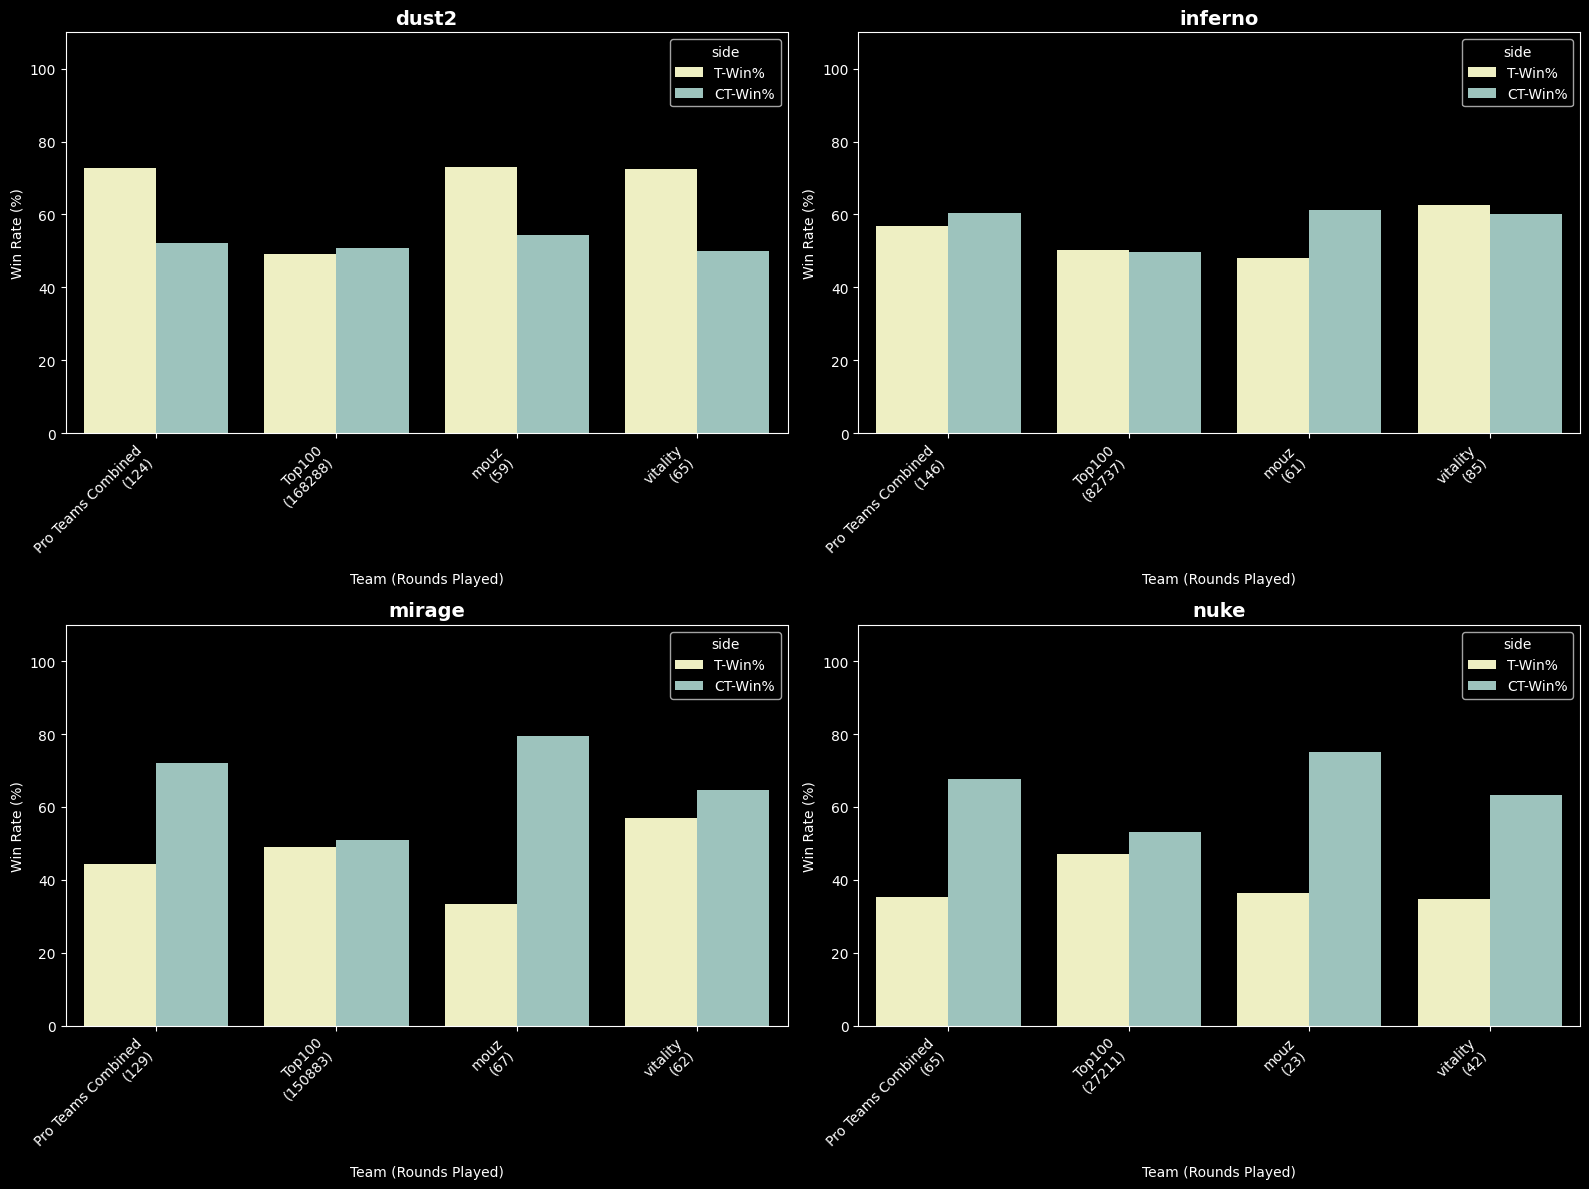

In [ ]:
maps = melted["map"].unique()
maps = [map_name for map_name in maps if map_name.lower() != 'train'] # We dont have top 100 data for train

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, map_name in enumerate(maps[:4]):
    map_data = melted[melted["map"] == map_name]

    ax = axes[i]

    sns.barplot(map_data,
                x="Team",
                y="win_rate",
                hue="side",
                ax=ax,
                palette={"T-Win%": "#f5f6bc", "CT-Win%": "#96cac1"}
                )

    ax.set_title(map_name, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_ylabel("Win Rate (%)")

    # Get rounds played for each team
    team_rounds = map_data.groupby(["Team"])["Rounds-Played"].first()
    ax.set_xlabel("Team (Rounds Played)")

    # Set x-axis labels with rounds played
    teams_in_plot_order = map_data["Team"].unique()
    labels = [f"{team}\n({team_rounds[team]})" for team in teams_in_plot_order]
    ax.set_xticklabels(labels, rotation=45, ha='right')

# Hide any unused subplots if there are fewer than 4 maps
for j in range(len(maps), 4):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<ipython-input-19-501304900>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated_stats = top_and_pro_stats.groupby(["Team", "side"]).apply(lambda x: (x["win_rate"] * x["Rounds-Played"]).sum() / x["Rounds-Played"].sum()).reset_index(name="win_rate")


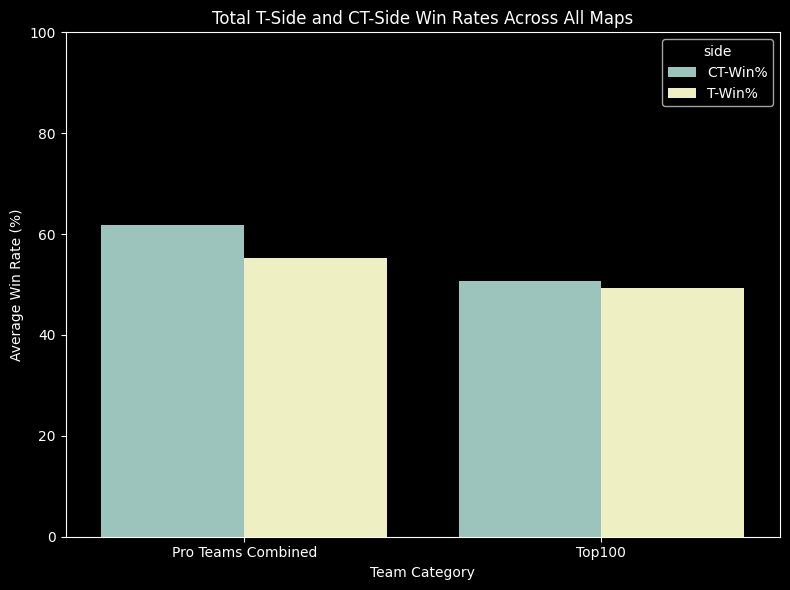

In [ ]:
top_and_pro_stats = melted[melted["Team"].isin(["Top100", "Pro Teams Combined"])]
aggregated_stats = top_and_pro_stats.groupby(["Team", "side"]).apply(lambda x: (x["win_rate"] * x["Rounds-Played"]).sum() / x["Rounds-Played"].sum()).reset_index(name="win_rate")
aggregated_stats

plt.figure(figsize=(8, 6))
sns.barplot(data=aggregated_stats, x="Team", y="win_rate", hue="side", palette={"T-Win%": "#f5f6bc", "CT-Win%": "#96cac1"})

plt.title("Total T-Side and CT-Side Win Rates Across All Maps")
plt.xlabel("Team Category")
plt.ylabel("Average Win Rate (%)")
plt.ylim(0, 100) # Win rates are percentages, so limit to 0-100
plt.tight_layout()
plt.show()

Similar to the maps function, we had to format the damages dataset into a format similar to the Top 100 weapons dataset. Grouped by attacker_name, weapon, and hitgoup allowed us to calculate where a player shot for each weapon.

We decided to aggregate some body parts based on damage multipliers.

In [ ]:
df_kills_vitality

,assistedflash,assister_X,assister_Y,assister_Z,assister_health,assister_place,assister_name,assister_side,attacker_X,attacker_Y,attacker_Z,attacker_health,attacker_place,attacker_name,attacker_side,attackerblind,attackerinair,ct_side,distance,dmg_armor,dmg_health,dominated,headshot,hitgroup,noreplay,noscope,penetrated,revenge,t_side,thrusmoke,tick,victim_X,victim_Y,victim_Z,victim_health,victim_place,victim_name,victim_side,weapon,weapon_fauxitemid,weapon_itemid,weapon_originalowner_xuid,wipe,round_num,map,opponent
3,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1390.82200,-532.72170,-415.468750,100.0,Hell,ZywOo,t,False,False,ct,5.622947,0,112,0,True,head,False,False,0,0,t,False,3893,1455.93770,-320.1936,-415.968750,100,Outside,910-,ct,glock,17293822569181872132,4.380575e+10,NaN,0,1,nuke,mongolz
4,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,571.40283,-553.30540,-399.968750,9.0,BombsiteA,ropz,t,False,False,ct,19.934908,0,93,0,True,head,False,False,0,0,t,False,4063,590.59375,-1337.9146,-415.968750,7,BombsiteA,Senzu,ct,glock,17293822569105195012,3.021953e+10,NaN,0,1,nuke,mongolz
5,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-155.86316,-1121.53710,-415.968750,9.0,Lobby,ropz,t,False,False,ct,13.916382,0,100,0,True,head,False,False,0,0,t,False,4956,345.49017,-1344.3538,-415.968750,80,BombsiteA,Techno4K,ct,glock,17293822569105195012,3.021953e+10,NaN,0,1,nuke,mongolz
8,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.48268,-1184.95060,-415.968750,100.0,Squeaky,ropz,t,False,False,ct,7.780745,13,91,0,True,head,False,False,0,0,t,True,10371,369.89465,-1426.8374,-415.968750,9,BombsiteA,Techno4K,ct,galilar,17293822569146023949,2.603865e+10,NaN,0,2,nuke,mongolz
9,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,284.94443,-934.26764,-391.968750,100.0,Hut,ZywOo,t,False,False,ct,20.249128,13,90,0,True,head,False,False,0,0,t,False,10378,984.57513,-673.9004,-127.968750,29,Rafters,Senzu,ct,galilar,17293822569166405645,2.639074e+10,NaN,0,2,nuke,mongolz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1509.14360,2327.71070,6.583417,100.0,ARamp,apEX,ct,False,False,ct,31.356600,15,106,0,True,head,False,False,0,0,t,False,208580,312.56802,2046.0454,96.789474,82,ExtendedA,xertioN,t,ak47,17293822569150152711,4.392670e+10,NaN,0,24,dust2,mouz
157,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1398.22790,2612.84230,78.658030,28.0,ARamp,apEX,ct,False,False,ct,23.215550,15,107,0,True,head,False,False,0,0,t,False,208733,485.27924,2650.6792,95.269770,20,ExtendedA,Brollan,t,ak47,17293822569150152711,4.392670e+10,NaN,0,24,dust2,mouz
158,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,539.17430,342.38132,1.566713,100.0,LongDoors,flameZ,ct,False,False,ct,5.241600,5,34,0,False,stomach,False,False,0,0,t,False,209595,644.84870,520.6472,0.924873,29,LongDoors,Spinx,t,ak47,17293822569179447303,4.380016e+10,NaN,0,24,dust2,mouz
159,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1560.38150,2152.10500,-9.381287,28.0,LongA,apEX,ct,False,False,ct,42.118153,4,32,0,False,stomach,False,False,0,0,t,False,210292,-91.14136,2194.0450,-127.716190,19,CTSpawn,torzsi,t,ak47,17293822569150152711,4.392670e+10,NaN,0,24,dust2,mouz


In [ ]:
#get weapons_statistics df for proplayers
def get_weapon_hit_where(df, team_name, weapons):

  copy = df.copy()
  num_rounds = df_rounds_mouz.shape[0] if team_name.lower() =="mouz" else df_rounds_vitality.shape[0]

  copy = copy[copy["weapon"].isin(weapons)]
  hit_count = copy.groupby(["attacker_name","weapon", "hitgroup"]).size().reset_index(name = "hit_count")
  total_hits = hit_count.groupby(["attacker_name", "weapon"])["hit_count"].sum().reset_index(name="total_hits")


  merged = hit_count.merge(total_hits, on = ["attacker_name", "weapon"])
  merged["hit_percentage"] = round(merged["hit_count"] / merged["total_hits"] * 100,1)


  pivot = merged.pivot(index = ["attacker_name", "weapon"], columns = ["hitgroup"], values = "hit_percentage").fillna(0).reset_index()

  #combine legs to one leg col and combine arms with chest
  pivot["chest"] = pivot["left_arm"] + pivot["right_arm"] + pivot["chest"] + pivot["neck"]
  pivot["leg"] = pivot["left_leg"] + pivot["right_leg"]

  result = pivot[["attacker_name","weapon", "head","chest", "leg"]]

  #add total_kills
  result = result.merge(total_hits, on= ["attacker_name", "weapon"], how = "left")

  #change weapon name for consistenty
  replace = {"glock": "Glock-18", "ak47": "AK-47", "m4a1_silencer":"M4A1-S", "m4a1":"M4A1", "usp_silencer": "USP-S", "deagle":"Desert Eagle",
             "galilar":"Galil AR", "p90": "P90", "awp": "AWP", "famas": "FAMAS", "hkp2000": "USP-S"}
  result=result.copy()
  result["weapon"] = result["weapon"].replace(replace)

  result.columns = ["Player", "Weapon","HS%", "Chest%", "Leg%", "Total Kills"]

  return result



In [ ]:
weapons = ['ak47', 'awp', 'deagle', 'famas', 'galilar','hkp2000',
       'glock', 'm4a1','m4a1_silencer', "usp_silencer"]

mouz_hit = get_weapon_hit_where(df_damages_mouz,"mouz", weapons)
vitality_hit = get_weapon_hit_where(df_damages_vitality, "vitality", weapons)

pro_hit_df = pd.concat([mouz_hit, vitality_hit], ignore_index=True)
pro_hit_df

,Player,Weapon,HS%,Chest%,Leg%,Total Kills
0,Brollan,AK-47,20.5,52.3,4.5,132
1,Brollan,AWP,0.0,100.0,0.0,2
2,Brollan,Desert Eagle,0.0,100.0,0.0,1
3,Brollan,FAMAS,6.7,66.7,13.4,15
4,Brollan,Galil AR,9.7,70.9,3.2,31
...,...,...,...,...,...,...
70,ropz,FAMAS,50.0,50.0,0.0,2
71,ropz,Galil AR,30.6,44.4,5.6,36
72,ropz,Glock-18,34.4,59.3,0.0,32
73,ropz,USP-S,45.9,45.9,0.0,37


In [ ]:
#import second weapons datasets
def get_weapon_stat_df(filename, weapons):
  base_path = "/content/DLfromGitHubTesting/"
  full_directory = base_path + filename
  weapon_statistics = pd.read_csv(base_path + filename)


  weapon_statistics["Player"] = "Top100"
  weapon_statistics = weapon_statistics.rename(columns={"HS %": "HS%", "Chest %": "Chest%", "Leg %": "Leg%"})

  columns_to_change = [col for col in weapon_statistics.columns if "%" in col]

  #change string percent in file to float
  for col in columns_to_change:
    weapon_statistics[col] = weapon_statistics[col].str.replace("%", "").astype(float)

  #just get weapons from parameter
  weapon_statistics = weapon_statistics[weapon_statistics["Weapon"].isin(weapons)]
  return weapon_statistics

weapon_statistics = get_weapon_stat_df("weapons_statistics.csv", pro_hit_df["Weapon"].unique())
weapon_statistics

,Weapon,KPR,HS%,Chest%,Leg%,Total Kills,Player
0,AK-47,1.2,17.8,59.4,16.7,"370,567",Top100
2,AWP,1.6,14.5,68.7,10.1,"164,754",Top100
3,M4A1,1.2,18.0,60.6,15.5,"104,012",Top100
4,USP-S,0.9,21.2,63.5,10.5,"94,958",Top100
5,Desert Eagle,0.9,28.5,58.7,9.0,"84,197",Top100
6,Glock-18,0.9,17.8,65.5,11.8,"83,899",Top100
7,Galil AR,1.1,18.1,57.6,18.4,"63,215",Top100
8,FAMAS,1.0,18.9,58.7,16.9,"50,834",Top100


In [ ]:
all_hit_df = pd.concat([pro_hit_df, weapon_statistics], ignore_index=True)


Just like the maps dataset, we melted weapons dataset for visualization.

In [ ]:
id_vars = ["Player","Weapon"]
value_vars = ["HS%", "Chest%", "Leg%"]
var_name = "Hitgroup"
value_name = "Hit Percentage"
melted_weapons = melt_df(all_hit_df, id_vars, value_vars, var_name, value_name)

melted_weapons


,Player,Weapon,Hitgroup,Hit Percentage
0,Brollan,AK-47,HS%,20.5
83,Brollan,AK-47,Chest%,52.3
166,Brollan,AK-47,Leg%,4.5
1,Brollan,AWP,HS%,0.0
84,Brollan,AWP,Chest%,100.0
...,...,...,...,...
119,xertioN,M4A1,Chest%,58.4
202,xertioN,M4A1,Leg%,7.0
35,xertioN,USP-S,HS%,50.0
118,xertioN,USP-S,Chest%,43.6


Simple visualization for three most popular weapons in the game.

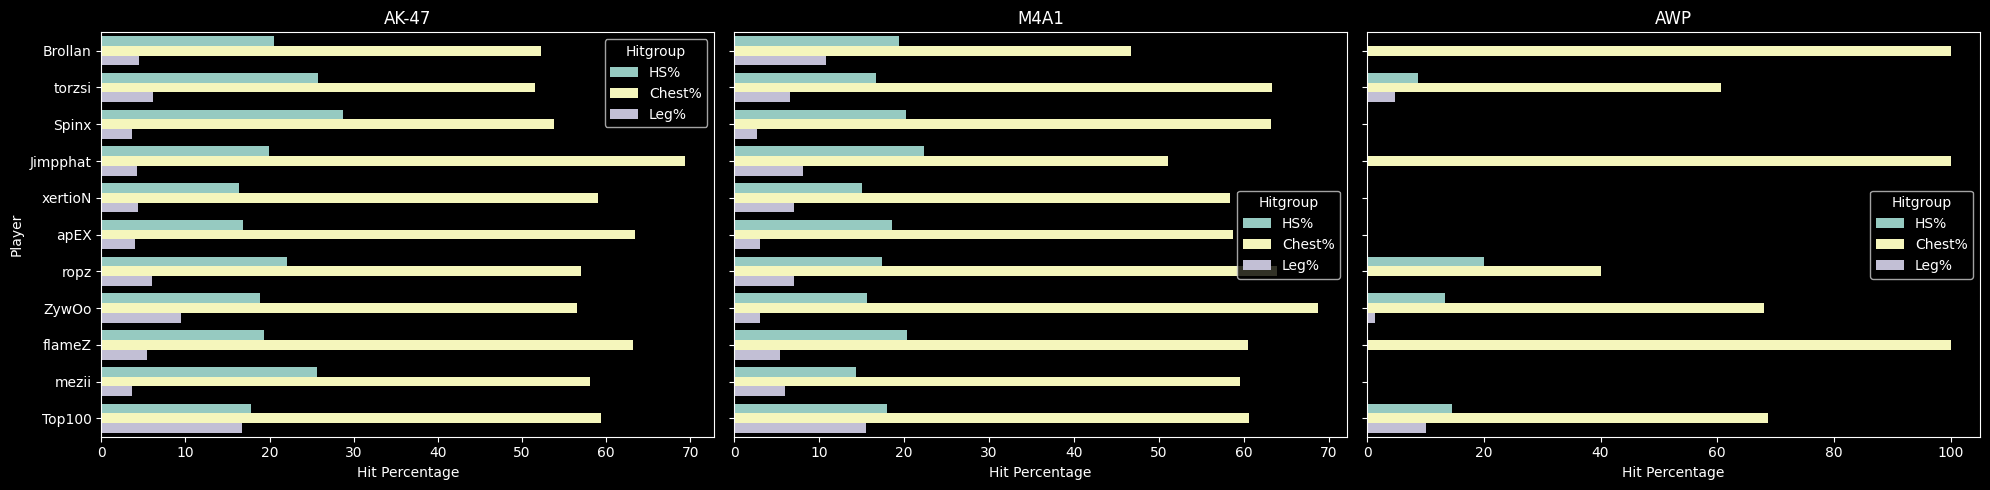

In [ ]:

weapons = ["AK-47", "M4A1", "AWP"]

figx, axes = plt.subplots(1,len(weapons), sharey = True, figsize = (20,5))

for ax, weapon in zip(axes, weapons):
  wepon_data = melted_weapons[melted_weapons["Weapon"] == weapon]
  sns.barplot(data = wepon_data,
              x = "Hit Percentage",
              y = "Player",
              hue = "Hitgroup",
              order = mouz_roster + vitality_roster + ["Top100"],
              ax = ax)

  ax.set_title(weapon)


plt.tight_layout()
plt.show()

In [ ]:
def aggregate_pro_players_weighted(df):
    aggregated = []

    for weapon in df['Weapon'].unique():
        weapon_data = df[df['Weapon'] == weapon].copy()

        if len(weapon_data) == 0:
            continue

        total_kills = weapon_data['Total Kills'].sum()

        if total_kills == 0:
            continue

        # Calculate weighted averages
        hs_weighted = (weapon_data['HS%'] * weapon_data['Total Kills']).sum() / total_kills
        chest_weighted = (weapon_data['Chest%'] * weapon_data['Total Kills']).sum() / total_kills
        leg_weighted = (weapon_data['Leg%'] * weapon_data['Total Kills']).sum() / total_kills

        # Calculate KPR if available in the dataframe
        result_dict = {
            'Player': 'Pro Teams Combined',
            'Weapon': weapon,
            'HS%': round(hs_weighted, 1),
            'Chest%': round(chest_weighted, 1),
            'Leg%': round(leg_weighted, 1),
            'Total Kills': total_kills
        }

        if 'KPR' in df.columns and not weapon_data['KPR'].isna().all():
            kpr_weighted = (weapon_data['KPR'] * weapon_data['Total Kills']).sum() / total_kills
            result_dict['KPR'] = round(kpr_weighted, 2)

        aggregated.append(result_dict)

    return pd.DataFrame(aggregated)

In [ ]:
pro_weighted_agg = aggregate_pro_players_weighted(pro_hit_df)
pro_weighted_agg

,Player,Weapon,HS%,Chest%,Leg%,Total Kills
0,Pro Teams Combined,AK-47,21.1,59.0,5.2,1879
1,Pro Teams Combined,AWP,10.6,64.0,3.2,189
2,Pro Teams Combined,Desert Eagle,34.7,59.7,1.4,72
3,Pro Teams Combined,FAMAS,17.2,63.1,7.3,122
4,Pro Teams Combined,Galil AR,17.4,57.1,7.1,322
5,Pro Teams Combined,Glock-18,32.2,59.0,1.7,295
6,Pro Teams Combined,USP-S,34.3,57.1,1.4,280
7,Pro Teams Combined,M4A1,18.2,59.2,5.9,1518


In [ ]:
def aggregate_pro_players_mean(df):
    agg_dict = {
        'HS%': 'mean',
        'Chest%': 'mean',
        'Leg%': 'mean',
        'Total Kills': 'sum'
    }

    # Add KPR if it exists
    if 'KPR' in df.columns:
        agg_dict['KPR'] = 'mean'

    aggregated = df.groupby('Weapon').agg(agg_dict).round(2).reset_index()
    aggregated['Player'] = 'Pro Teams Mean'

    # Reorder columns
    base_cols = ['Player', 'Weapon', 'HS%', 'Chest%', 'Leg%', 'Total Kills']
    if 'KPR' in aggregated.columns:
        base_cols.insert(-1, 'KPR')  # Insert KPR before Total Kills

    return aggregated[base_cols]

In [ ]:
pro_mean_agg = aggregate_pro_players_mean(pro_hit_df)
pro_mean_agg

,Player,Weapon,HS%,Chest%,Leg%,Total Kills
0,Pro Teams Mean,AK-47,21.42,58.45,5.14,1879
1,Pro Teams Mean,AWP,7.00,78.10,1.02,189
2,Pro Teams Mean,Desert Eagle,39.20,55.17,1.67,72
3,Pro Teams Mean,FAMAS,21.50,64.09,4.98,122
4,Pro Teams Mean,Galil AR,18.37,55.98,7.07,322
5,Pro Teams Mean,Glock-18,33.55,56.66,1.61,295
6,Pro Teams Mean,M4A1,18.00,59.40,5.97,1518
7,Pro Teams Mean,USP-S,34.24,56.96,1.29,280


Add kills per round. The formula is simply KPR = kills / rounds

In [ ]:
def add_kpr_to_pro_data(pro_hit_df, df_rounds_mouz, df_rounds_vitality, mouz_roster, vitality_roster):
    pro_with_kpr = pro_hit_df.copy()

    # Get round counts for each team
    mouz_rounds = df_rounds_mouz.shape[0]
    vitality_rounds = df_rounds_vitality.shape[0]

    # Add KPR calculation
    def calculate_kpr(row):
        if row['Player'] in mouz_roster:
            return round(row['Total Kills'] / mouz_rounds, 2)
        elif row['Player'] in vitality_roster:
            return round(row['Total Kills'] / vitality_rounds, 2)
        else:
            return 0  # Default case

    pro_with_kpr['KPR'] = pro_with_kpr.apply(calculate_kpr, axis=1)

    return pro_with_kpr

In [ ]:
pro_hit_df_with_kpr = add_kpr_to_pro_data(pro_hit_df, df_rounds_mouz, df_rounds_vitality, mouz_roster, vitality_roster)
pro_hit_df_with_kpr

,Player,Weapon,HS%,Chest%,Leg%,Total Kills,KPR
0,Brollan,AK-47,20.5,52.3,4.5,132,0.55
1,Brollan,AWP,0.0,100.0,0.0,2,0.01
2,Brollan,Desert Eagle,0.0,100.0,0.0,1,0.00
3,Brollan,FAMAS,6.7,66.7,13.4,15,0.06
4,Brollan,Galil AR,9.7,70.9,3.2,31,0.13
...,...,...,...,...,...,...,...
70,ropz,FAMAS,50.0,50.0,0.0,2,0.01
71,ropz,Galil AR,30.6,44.4,5.6,36,0.13
72,ropz,Glock-18,34.4,59.3,0.0,32,0.11
73,ropz,USP-S,45.9,45.9,0.0,37,0.13


In [ ]:
def aggregate_by_team(pro_hit_df_with_kpr, mouz_roster, vitality_roster):
    # Filter the KPR-enhanced dataframe by team
    mouz_data = pro_hit_df_with_kpr[pro_hit_df_with_kpr['Player'].isin(mouz_roster)]
    vitality_data = pro_hit_df_with_kpr[pro_hit_df_with_kpr['Player'].isin(vitality_roster)]

    # Get team aggregations using the weighted method
    mouz_agg = aggregate_pro_players_weighted(mouz_data)
    mouz_agg['Player'] = 'MOUZ'

    vitality_agg = aggregate_pro_players_weighted(vitality_data)
    vitality_agg['Player'] = 'Vitality'

    return pd.concat([mouz_agg, vitality_agg], ignore_index=True)

In [ ]:
team_specific_agg = aggregate_by_team(pro_hit_df_with_kpr, mouz_roster, vitality_roster)
team_specific_agg

,Player,Weapon,HS%,Chest%,Leg%,Total Kills,KPR
0,MOUZ,AK-47,22.2,57.7,4.3,693,0.63
1,MOUZ,AWP,8.5,61.7,4.7,107,0.42
2,MOUZ,Desert Eagle,34.5,55.1,3.5,29,0.05
3,MOUZ,FAMAS,20.7,58.6,10.3,58,0.08
4,MOUZ,Galil AR,16.8,58.1,5.6,143,0.13
5,MOUZ,Glock-18,31.3,59.2,2.7,147,0.13
6,MOUZ,USP-S,31.1,63.7,1.5,135,0.12
7,MOUZ,M4A1,18.8,56.7,6.6,783,0.74
8,Vitality,AK-47,20.5,59.7,5.7,1186,0.84
9,Vitality,AWP,13.4,67.1,1.2,82,0.24


In [ ]:
pro_weighted_agg = aggregate_pro_players_weighted(pro_hit_df_with_kpr)
pro_mean_agg = aggregate_pro_players_mean(pro_hit_df_with_kpr)

comparison_df = pd.concat([
    pro_weighted_agg,
    weapon_statistics[['Player', 'Weapon', 'HS%', 'Chest%', 'Leg%', 'Total Kills', "KPR"]]
], ignore_index=True)

team_comparison = pd.concat([
    team_specific_agg,
    weapon_statistics[['Player', 'Weapon', 'HS%', 'Chest%', 'Leg%', 'Total Kills', 'KPR']]
], ignore_index=True)

print("Weighted Average Comparison:")
#print(comparison_df)
print("Team-specific Comparison with KPR:")
#print(team_comparison)

melted_comparison = melt_df(comparison_df,
                                 id_vars=["Player", "Weapon"],
                                 value_vars=["HS%", "Chest%", "Leg%", 'KPR'],
                                 var_name="Hitgroup",
                                 value_name="Hit Percentage")

melted_team_comparison = melt_df(team_comparison,
                                      id_vars=["Player", "Weapon"],
                                      value_vars=["HS%", "Chest%", "Leg%", 'KPR'],
                                      var_name="Hitgroup",
                                      value_name="Hit Percentage")

print("\nMelted for visualization:")
print(melted_comparison)

Weighted Average Comparison:
Team-specific Comparison with KPR:

Melted for visualization:
                Player Weapon Hitgroup  Hit Percentage
0   Pro Teams Combined  AK-47      HS%           21.10
16  Pro Teams Combined  AK-47   Chest%           59.00
32  Pro Teams Combined  AK-47     Leg%            5.20
48  Pro Teams Combined  AK-47      KPR            0.76
1   Pro Teams Combined    AWP      HS%           10.60
..                 ...    ...      ...             ...
58              Top100   M4A1      KPR            1.20
11              Top100  USP-S      HS%           21.20
27              Top100  USP-S   Chest%           63.50
43              Top100  USP-S     Leg%           10.50
59              Top100  USP-S      KPR            0.90

[64 rows x 4 columns]


The plot is created for all the pro players combined and Top 100 players. While it may be important to visualize on a per player basis, aggregating all the pros helps us compare pro vs top 100 players better.

To compare between the winning and the 2nd place team, we also created visualization for that below

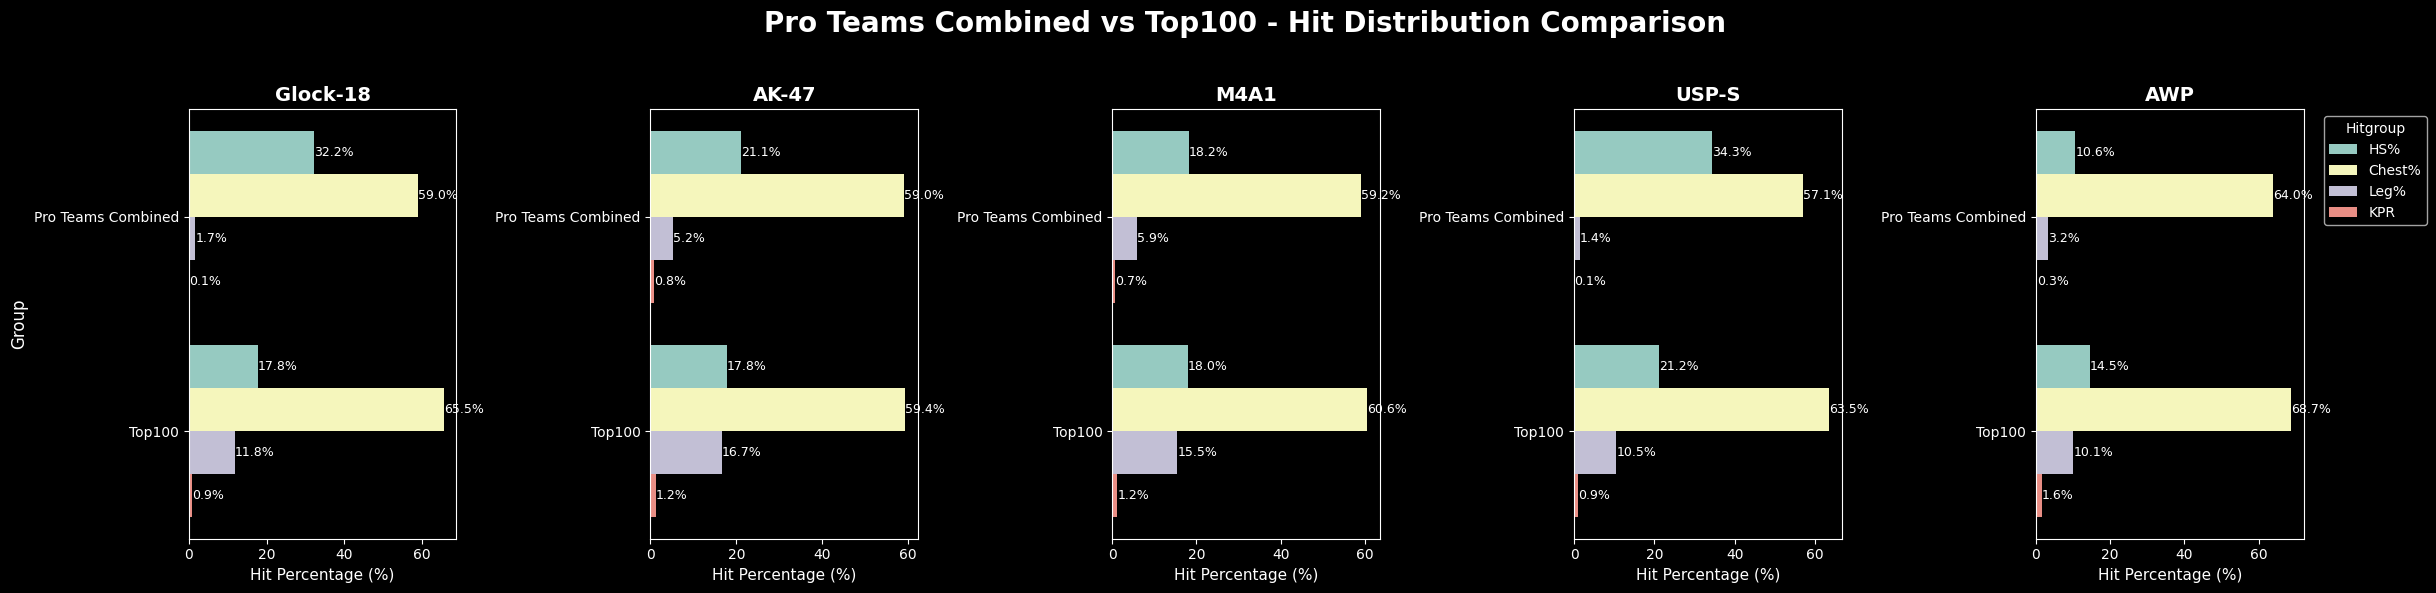

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
fig.suptitle('Pro Teams Combined vs Top100 - Hit Distribution Comparison', fontsize=20, fontweight='bold', y=0.98)
weapons_viz = ["Glock-18","AK-47","M4A1","USP-S","AWP"]
for i, weapon in enumerate(weapons_viz):
    weapon_data = melted_comparison[melted_comparison["Weapon"] == weapon]

    if len(weapon_data) == 0:
        axes[i].text(0.5, 0.5, f'No data for {weapon}',
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{weapon}', fontsize=14, fontweight='bold')
        continue

    sns.barplot(data=weapon_data,
                x="Hit Percentage",
                y="Player",
                hue="Hitgroup",
                order=["Pro Teams Combined", "Top100"],
                hue_order=["HS%", "Chest%", "Leg%", 'KPR'],
                ax=axes[i])

    axes[i].set_title(f'{weapon}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Hit Percentage (%)', fontsize=11)

    if i == 0:
        axes[i].set_ylabel('Group', fontsize=12)
    else:
        axes[i].set_ylabel('')

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', fontsize=9)

    if i == len(weapons_viz) - 1:
        axes[i].legend(title='Hitgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.98, 0.95])
plt.show()


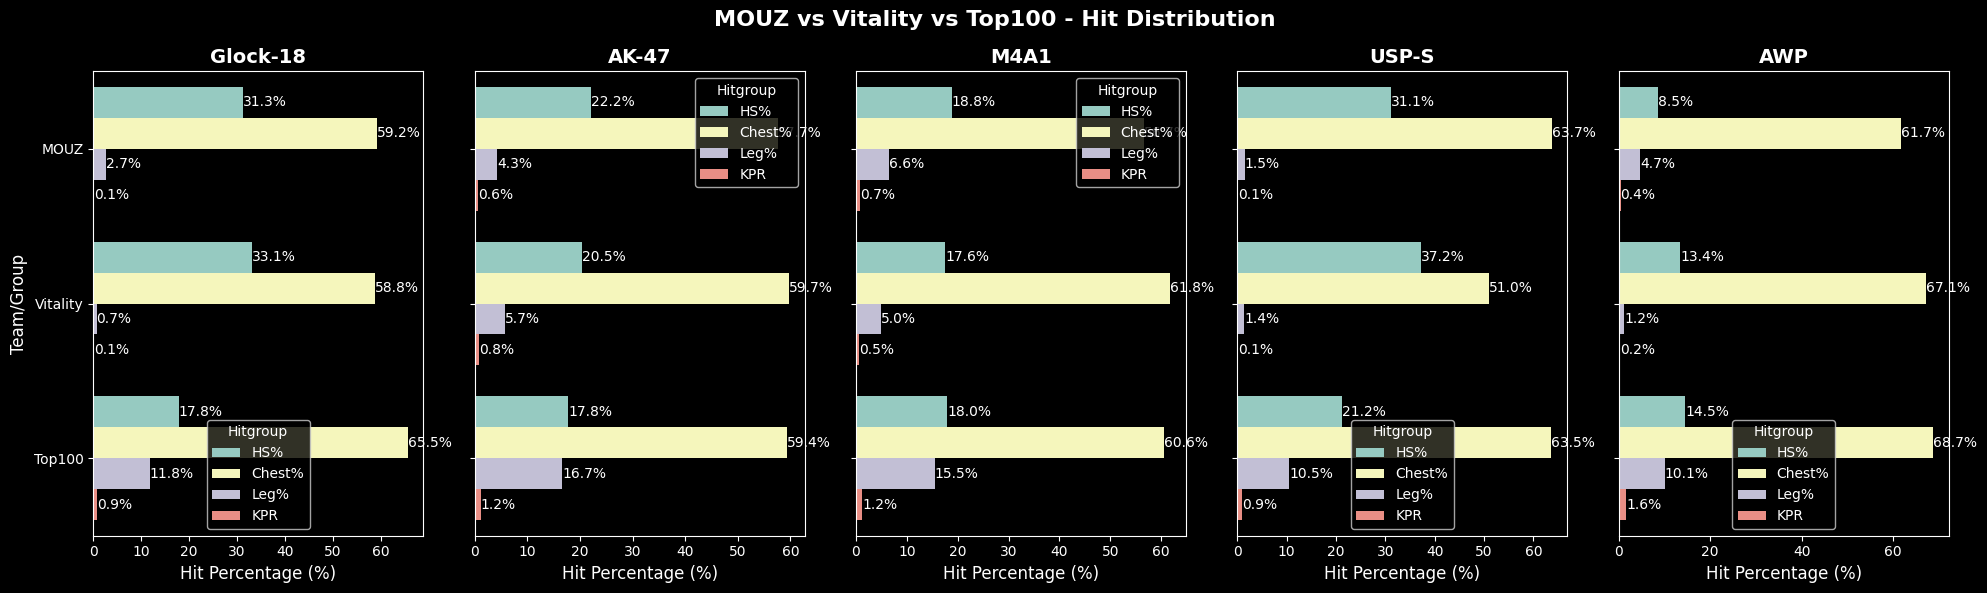

In [ ]:
fig2, axes2 = plt.subplots(1, len(weapons_viz), sharey=True, figsize=(20, 6))
fig2.suptitle('MOUZ vs Vitality vs Top100 - Hit Distribution', fontsize=16, fontweight='bold')

for ax, weapon in zip(axes2, weapons_viz):
    weapon_data = melted_team_comparison[melted_team_comparison["Weapon"] == weapon]

    sns.barplot(data=weapon_data,
                x="Hit Percentage",
                y="Player",
                hue="Hitgroup",
                order=["MOUZ", "Vitality", "Top100"],
                hue_order=["HS%", "Chest%", "Leg%", 'KPR'],
                ax=ax)

    ax.set_title(f'{weapon}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hit Percentage (%)', fontsize=12)
    if ax == axes2[0]:
        ax.set_ylabel('Team/Group', fontsize=12)
    else:
        ax.set_ylabel('')

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def create_all_weapons_table():
    """
    Create a comprehensive table for all weapons
    """
    all_results = []

    for weapon in weapons_viz:
        weapon_data = melted_team_comparison[melted_team_comparison["Weapon"] == weapon]

        if len(weapon_data) == 0:
            continue

        top100_data = weapon_data[weapon_data["Player"] == "Top100"].set_index("Hitgroup")["Hit Percentage"]
        team_data = weapon_data[weapon_data["Player"] != "Top100"].copy()

        for _, row in team_data.iterrows():
            team = row["Player"]
            hitgroup = row["Hitgroup"]
            team_performance = row["Hit Percentage"]
            baseline = top100_data[hitgroup]
            difference = team_performance - baseline

            all_results.append({
                'Weapon': weapon,
                'Team': team,
                'Hitgroup': hitgroup,
                'Team Performance': team_performance,
                'Top100 Baseline': baseline,
                'Difference': difference
            })

    return pd.DataFrame(all_results)
all_weapons_df = create_all_weapons_table()
all_weapons_df.head()

,Weapon,Team,Hitgroup,Team Performance,Top100 Baseline,Difference
0,Glock-18,MOUZ,HS%,31.30,17.8,13.50
1,Glock-18,MOUZ,Chest%,59.20,65.5,-6.30
2,Glock-18,MOUZ,Leg%,2.70,11.8,-9.10
3,Glock-18,MOUZ,KPR,0.13,0.9,-0.77
4,Glock-18,Vitality,HS%,33.10,17.8,15.30


Using the data from the analysis below, we plot the difference in weapon performace from the Top 100.

From the visualization, we can clearly see that the Top 100 players more frequently hit legs where as the pros more consistently hit heads.

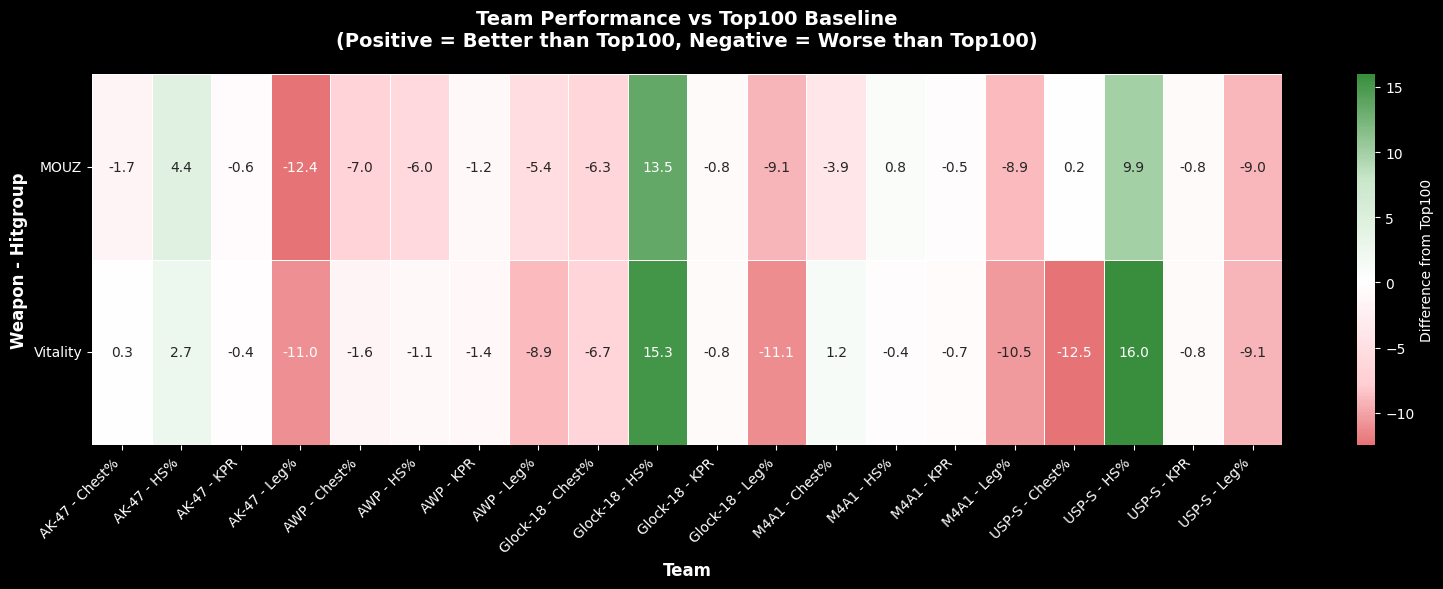

In [ ]:
def create_comprehensive_heatmap():
    all_weapons_df['Weapon_Hitgroup'] = all_weapons_df['Weapon'] + ' - ' + all_weapons_df['Hitgroup']

    # Pivot the data
    heatmap_data = all_weapons_df.pivot(index='Team', columns='Weapon_Hitgroup', values='Difference')

    # Create the plot
    plt.figure(figsize=(16, 6))

    # Create custom colormap (red for negative, white for neutral, green for positive)
    # Thanks power toys
    colors = ['#d32f2f', '#ffcdd2', '#ffffff', '#c8e6c9', '#388e3c']
    n_bins = 100
    cmap = sns.blend_palette(colors, n_colors=n_bins, as_cmap=True)

    # Create heatmap
    ax = sns.heatmap(heatmap_data,
                     annot=True,
                     fmt='.1f',
                     cmap=cmap,
                     center=0,
                     cbar_kws={'label': 'Difference from Top100'},
                     linewidths=0.5,
                     annot_kws={'size': 10})

    plt.title('Team Performance vs Top100 Baseline\n(Positive = Better than Top100, Negative = Worse than Top100)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Team', fontsize=12, fontweight='bold')
    plt.ylabel('Weapon - Hitgroup', fontsize=12, fontweight='bold')

    # Rotate labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # Adjust layout
    plt.tight_layout()
    plt.show()
create_comprehensive_heatmap()

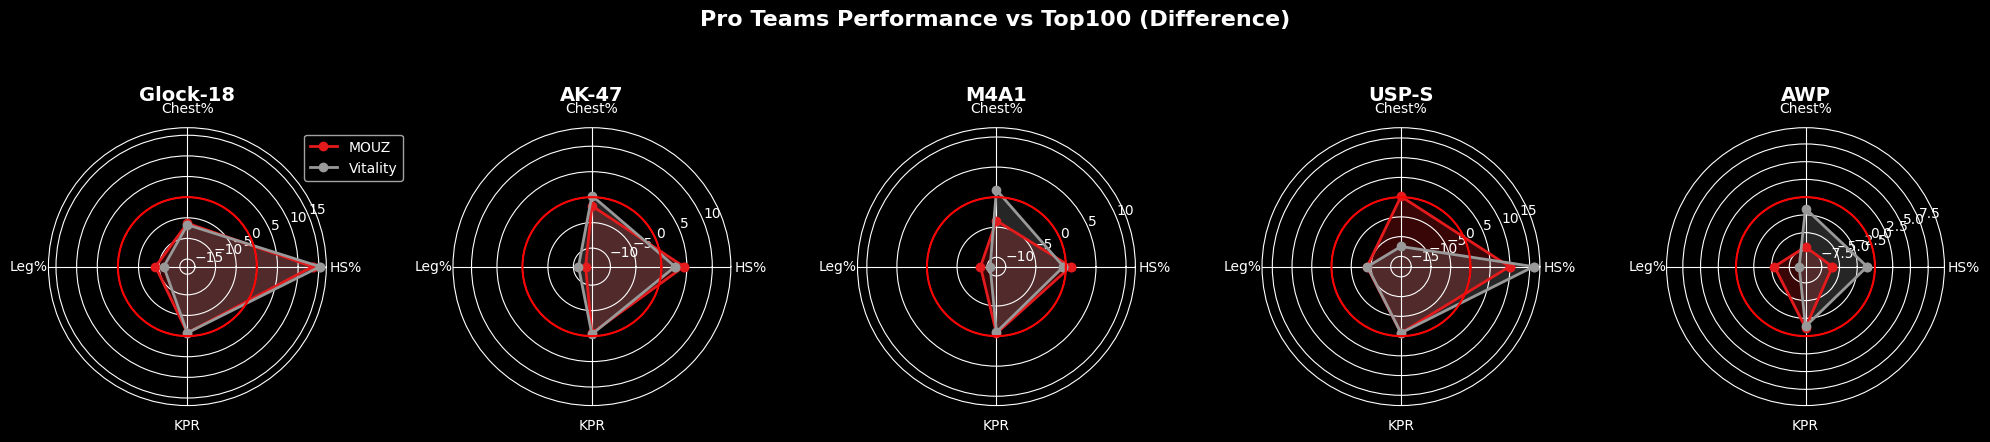

In [ ]:
def create_spider_plot():
    hitgroups = ["HS%", "Chest%", "Leg%", 'KPR']

    fig, axes = plt.subplots(1, len(weapons_viz), figsize=(20, 5), subplot_kw=dict(projection='polar'))
    fig.suptitle('Pro Teams Performance vs Top100 (Difference)', fontsize=16, fontweight='bold')

    if len(weapons_viz) == 1:
        axes = [axes]

    for ax, weapon in zip(axes, weapons_viz):
        weapon_data = melted_team_comparison[melted_team_comparison["Weapon"] == weapon]

        if len(weapon_data) == 0:
            continue
        top100_data = weapon_data[weapon_data["Player"] == "Top100"].set_index("Hitgroup")["Hit Percentage"]

        if len(top100_data) == 0:
            continue
        team_data = weapon_data[weapon_data["Player"] != "Top100"].copy()

        if len(team_data) == 0:
            continue
        team_data["Difference"] = team_data.apply(
            lambda row: row["Hit Percentage"] - top100_data[row["Hitgroup"]], axis=1
        )
        angles = [n / float(len(hitgroups)) * 2 * pi for n in range(len(hitgroups))]
        angles += angles[:1]

        teams = team_data["Player"].unique()
        colors = plt.cm.Set1(np.linspace(0, 1, len(teams)))

        for team, color in zip(teams, colors):
            team_values = []
            for hitgroup in hitgroups:
                team_hitgroup_data = team_data[(team_data["Player"] == team) &
                                             (team_data["Hitgroup"] == hitgroup)]
                if len(team_hitgroup_data) > 0:
                    team_values.append(team_hitgroup_data["Difference"].iloc[0])
                else:
                    team_values.append(0)

            team_values += team_values[:1]

            ax.plot(angles, team_values, 'o-', linewidth=2, label=team, color=color)
            ax.fill(angles, team_values, alpha=0.25, color=color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(hitgroups)
        ax.set_title(f'{weapon}', fontsize=14, fontweight='bold', pad=20)

        ax.axhline(y=0, color='red', linestyle='-', alpha=1)
        ax.grid(True)

        all_values = team_data["Difference"].values
        if len(all_values) > 0:
            max_val = max(abs(all_values.min()), abs(all_values.max()))
            ax.set_ylim(-max_val * 1.1, max_val * 1.1)

        if ax == axes[0]:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    plt.tight_layout()
    plt.show()

create_spider_plot()

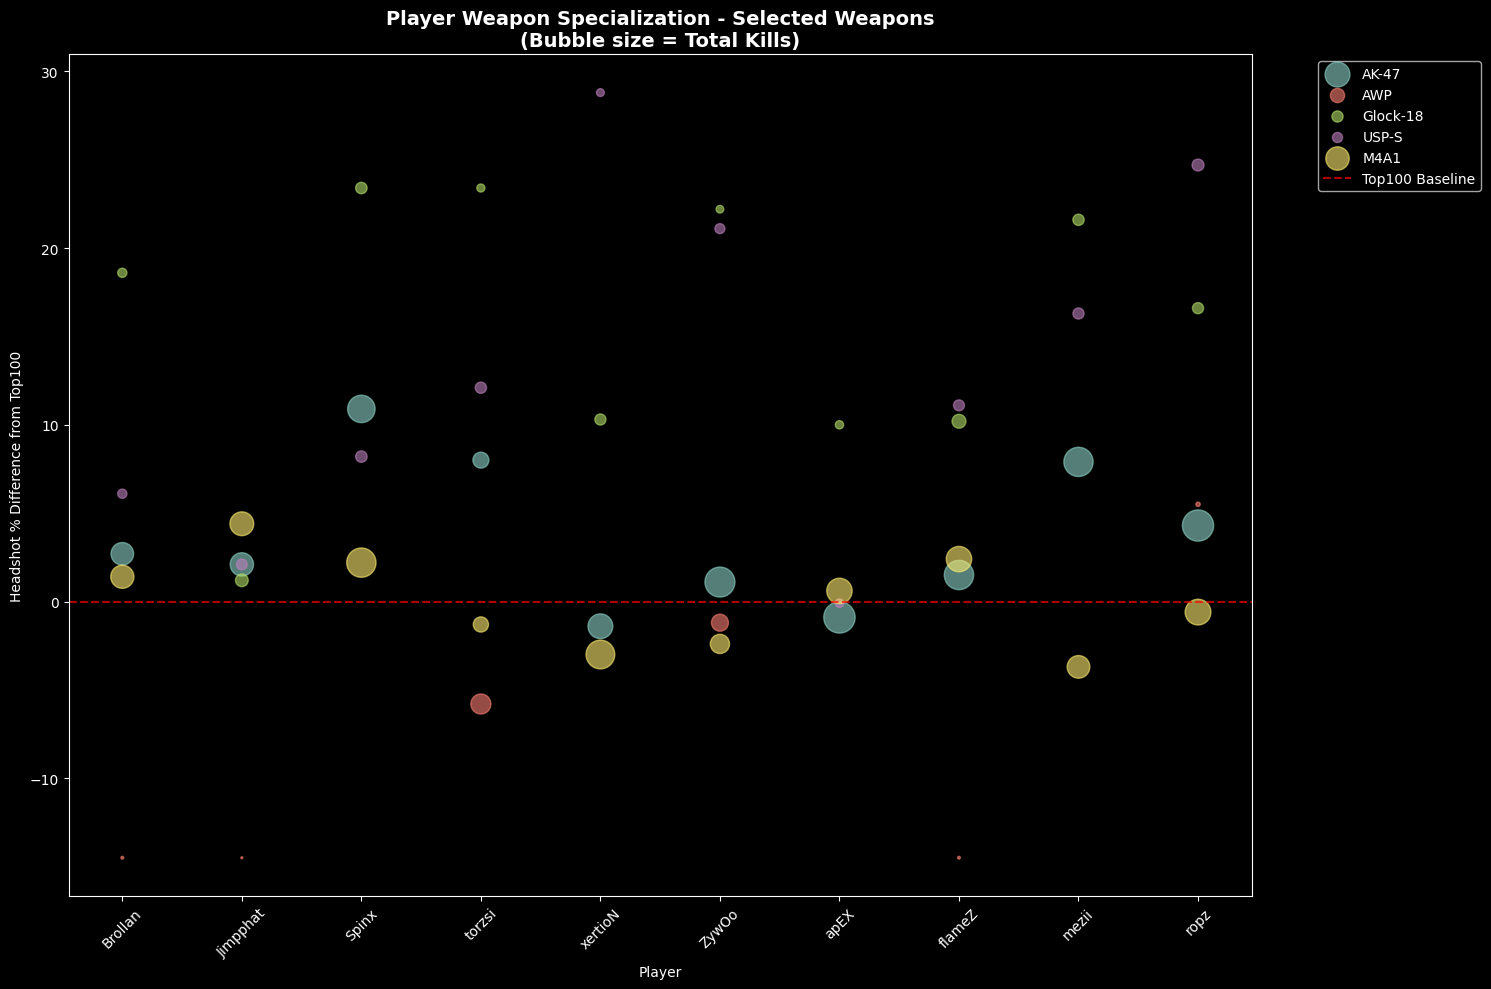

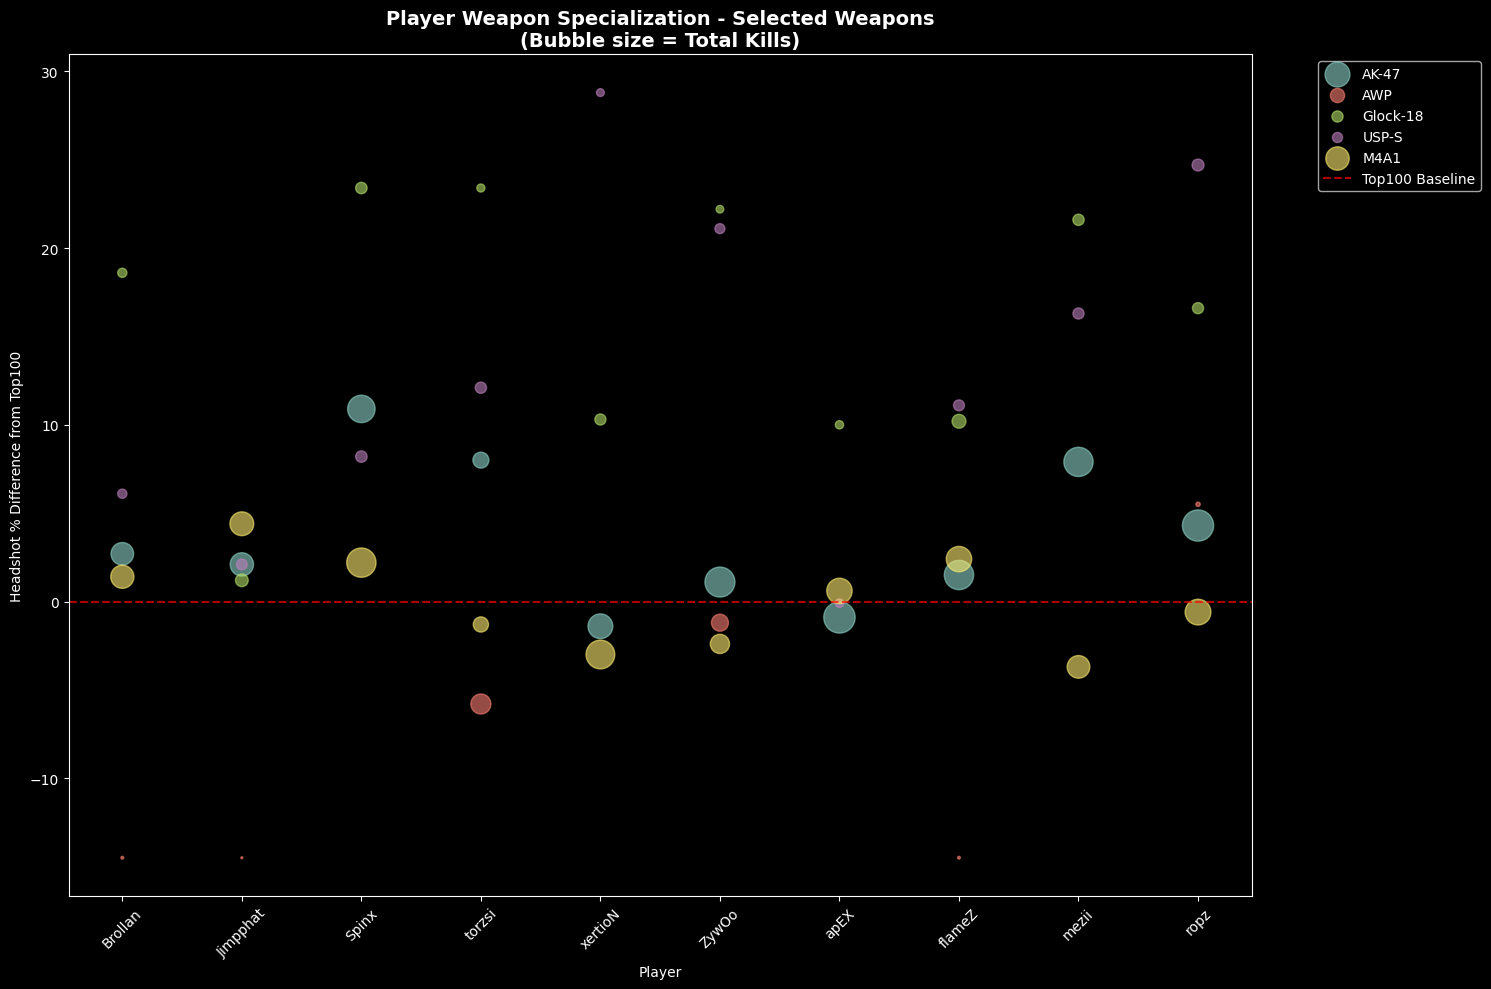

In [ ]:
def create_weapon_specialization_chart(weapon_df, top100_baseline):
    selected_weapons = ["Glock-18", "AK-47", "M4A1", "USP-S", "AWP"]

    comparison_data = []

    for _, player_row in weapon_df.iterrows():
        if player_row['Player'] not in ['Top100', 'Pro Teams Combined']:
            weapon = player_row['Weapon']

            # Only process if weapon is in our selected list
            if weapon in selected_weapons:
                baseline = top100_baseline[top100_baseline['Weapon'] == weapon]

                if len(baseline) > 0:
                    baseline_hs = baseline['HS%'].iloc[0]
                    player_hs = player_row['HS%']
                    difference = player_hs - baseline_hs

                    comparison_data.append({
                        'Player': player_row['Player'],
                        'Weapon': weapon,
                        'HS_Difference': difference,
                        'Total_Kills': player_row['Total Kills']
                    })

    df_comparison = pd.DataFrame(comparison_data)

    if len(df_comparison) == 0:
        print("No comparison data available")
        return None

    # Create bubble chart
    fig, ax = plt.subplots(figsize=(15, 10))

    weapons = df_comparison['Weapon'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(weapons)))

    for weapon, color in zip(weapons, colors):
        weapon_data = df_comparison[df_comparison['Weapon'] == weapon]
        scatter = ax.scatter(weapon_data['Player'], weapon_data['HS_Difference'],
                           s=weapon_data['Total_Kills']*2, alpha=0.6,
                           color=color, label=weapon)

    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Top100 Baseline')
    ax.set_xlabel('Player')
    ax.set_ylabel('Headshot % Difference from Top100')
    ax.set_title('Player Weapon Specialization - Selected Weapons\n(Bubble size = Total Kills)',
                 fontsize=14, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()

    return fig

create_weapon_specialization_chart(pro_hit_df, weapon_statistics)

Import grenades dataset. And drop duplicate entity_id.
Entity id provides unique ids for each grenade in a game. So removing duplicate allows us to only have data for 1 grenade per round per map. Although it may be necessary to keep the original dataset, for our analysis, we only needed one datapoint per entity_id.

In [ ]:
df_grenades_vitality = get_df("vitality", "grenades", roster = vitality_roster)
#removes duplicate utility
df_grenades_vitality = df_grenades_vitality.drop_duplicates(subset = ["entity_id"])

df_grenades_mouz = get_df("mouz", "grenades", roster = mouz_roster)
#removes duplicate utility
df_grenades_mouz = df_grenades_mouz.drop_duplicates(subset = ["entity_id"])

In [ ]:
df_grenades_vitality.shape

(930, 10)

First, clean up the dataset including changing grenade names into something more redable. The parser parsed the grenade names differently based on the side the thrower was in so we combined each grenade types into one.

In [ ]:
def clean_util(df, team_name):
  df = df.groupby(["map", "grenade_type"]).size().reset_index(name = "util_thrown").fillna(0)

  grenade_map = {"CFlashbang": "flash",
    "CFlashbangProjectile": "flash",
    "CHEGrenade": "grenade",
    "CHEGrenadeProjectile": "grenade",
    "CIncendiaryGrenade": "incendiary",
    "CMolotovGrenade": "incendiary",
    "CMolotovProjectile": "incendiary",
    "CSmokeGrenade": "smoke",
    "CSmokeGrenadeProjectile": "smoke",
    "CDecoyGrenade": "decoy",
    "CDecoyProjectile": "decoy",
    }

  grenades = ['hegrenade', 'smokegrenade', 'inferno', 'molotov','flashbang']
  util = ["Flash", "Grenade", "Incendiary", "Smoke", "Decoy"]

  df["grenade_cat"] = df["grenade_type"].map(grenade_map)
  grouped = df.groupby(["map", "grenade_cat"])["util_thrown"].sum().reset_index()

  pivotted = grouped.pivot(index = "map", columns = "grenade_cat", values = "util_thrown").reset_index().fillna(0)


  return pivotted

In [ ]:
vit_util = clean_util(df_grenades_vitality, "vitality")
mouz_util = clean_util(df_grenades_mouz, "mouz")
vit_util

grenade_cat,map,decoy,flash,grenade,incendiary,smoke
0,dust2,0.0,56.0,36.0,49.0,51.0
1,inferno,1.0,60.0,44.0,54.0,55.0
2,mirage,0.0,0.0,1.0,0.0,0.0
3,nuke,0.0,109.0,88.0,137.0,172.0
4,train,0.0,5.0,3.0,2.0,7.0


In [ ]:
vit_util_stats = vit_map_stats.merge(vit_util, how = "left")
mouz_util_stats = mouz_map_stats.merge(mouz_util, how = "left")
vit_util_stats

,map,CT-Win,T-Win,CT-Played,T-Played,T-Win%,CT-Win%,Rounds-Played,Round-Win%,Team,decoy,flash,grenade,incendiary,smoke
0,dust2,18,21,36,29,72.4,50.0,65,60.00,vitality,0.0,56.0,36.0,49.0,51.0
1,inferno,27,25,45,40,62.5,60.0,85,61.18,vitality,1.0,60.0,44.0,54.0,55.0
2,mirage,22,16,34,28,57.1,64.7,62,61.29,vitality,0.0,0.0,1.0,0.0,0.0
3,nuke,12,8,19,23,34.8,63.2,42,47.62,vitality,0.0,109.0,88.0,137.0,172.0
4,train,2,4,7,9,44.4,28.6,16,37.50,vitality,0.0,5.0,3.0,2.0,7.0


Add utility damages to the dataframe.

In [ ]:
def add_util_damage(df, team_name, drop):
  damages_df = None
  assist = None
  grenades = ['hegrenade', 'smokegrenade', 'inferno', 'molotov','flashbang']
  grenade_map = {
    "hegrenade": "grenade_dmg",
    "smokegrenade": "smoke_dmg",
    "inferno": "incendiary_dmg",
    "molotov": "incendiary_dmg",
    "flashbang":"flash_dmg"}

  if team_name == "mouz":
    damages_df = df_damages_mouz.groupby(["map", "weapon"])["dmg_health_real"].sum().reset_index()
    assist = df_kills_mouz.groupby("map")["assistedflash"].sum().reset_index(name ="assisted_flash_kills")
  elif team_name == "vitality":
    damages_df = df_damages_vitality.groupby(["map", "weapon"])["dmg_health_real"].sum().reset_index()
    assist = df_kills_vitality.groupby("map")["assistedflash"].sum().reset_index(name ="assisted_flash_kills")

  util_damage = damages_df[damages_df["weapon"].isin(grenades)].copy()
  util_damage["grenade"] = util_damage["weapon"].map(grenade_map)
  util_damage = util_damage.groupby(["map", "grenade"])["dmg_health_real"].sum().reset_index()

  #pivot to match df
  pivotted_util_damage = util_damage.pivot(index = "map", columns = "grenade", values = "dmg_health_real").reset_index().fillna(0)
  merged = df.merge(pivotted_util_damage, how = "left")
  merged = merged.merge(assist, how = "left")
  #calculate utility damage per round
  dmg_col = [x for x in merged.columns if "dmg" in x]
  for x in dmg_col:
    merged[x] = round(merged[x] / merged["Rounds-Played"],4)

  merged = merged.drop(drop, axis= 1)
  return merged

At the end, we complined aggregated dataset for rounds and utility datasets. This gives a clean picture of utility usages and their effectiveness in dealing damage.

Couple things to note, in a typical game, decoy is rarely bought since it takes up valuable and limited utility spots and it serves nearly no purpose.

In [ ]:
drop = ["CT-Win", "T-Win", "CT-Played", "T-Played"]

vit_util_full_stat = add_util_damage(vit_util_stats, "vitality",drop)
mouz_util_full_stat = add_util_damage(mouz_util_stats, "mouz",drop)
mouz_util_full_stat

,map,T-Win%,CT-Win%,Rounds-Played,Round-Win%,Team,decoy,flash,grenade,incendiary,smoke,grenade_dmg,incendiary_dmg,smoke_dmg,assisted_flash_kills
0,dust2,73.1,54.5,59,62.71,mouz,0.0,60.0,53.0,60.0,72.0,22.1017,9.0847,0.0847,10
1,inferno,48.0,61.1,61,55.74,mouz,1.0,140.0,116.0,135.0,147.0,30.2131,9.1311,0.0656,7
2,mirage,33.3,79.4,67,56.72,mouz,0.0,2.0,1.0,4.0,4.0,15.4627,3.3134,0.1791,8
3,nuke,36.4,75.0,23,56.52,mouz,0.0,5.0,14.0,15.0,11.0,17.1739,7.0435,0.0000,1
4,train,83.3,100.0,15,86.67,mouz,0.0,11.0,11.0,16.0,18.0,32.0667,17.0667,0.3333,6


In [ ]:
vitality_rounds = prepare_team_side_data(df_rounds_vitality, df_kills_vitality, 'Vitality', vitality_roster)
mouz_rounds = prepare_team_side_data(df_rounds_mouz, df_kills_mouz, 'MOUZ', mouz_roster)
vitality_rounds

,round_num,start,freeze_end,end,official_end,winner,reason,map,opponent,bomb_plant,bomb_site,vitality_side,vitality_won
0,1,1,1262,6287,6607,ct,t_killed,inferno,legacy,NaN,NaN,ct,1
1,2,6607,7887,13633,13953,ct,t_killed,inferno,legacy,NaN,NaN,ct,1
2,3,13953,15233,16951,17271,ct,t_killed,inferno,legacy,NaN,NaN,ct,1
3,1,1,1266,6723,7043,ct,bomb_defused,nuke,mongolz,4674.0,bombsite_b,t,0
4,2,7043,8323,12735,13055,ct,bomb_defused,nuke,mongolz,11135.0,bombsite_b,t,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,15,120639,121919,127648,127968,t,bomb_exploded,train,falcons,125024.0,bombsite_b,ct,0
280,16,127968,129248,132197,132517,t,ct_killed,train,falcons,NaN,not_planted,ct,0
281,17,132517,135915,142315,142635,ct,t_killed,train,falcons,NaN,not_planted,ct,1
282,18,142635,143915,150822,151142,t,ct_killed,train,falcons,150660.0,bombsite_b,ct,0


This function does similar to what we calculated earlier. But rather than aggregating the data, we left the rows as is and merged additional round data (utility count and damage) onto it.

In [ ]:
from functools import reduce

def prep_grenade_for_plot(round_df, grenade_df, kills_df, damages_df,team_name):
  #prep rounds data
  round_df = round_df.copy()
  round_df = round_df[["round_num", "map", "opponent", f"{team_name}_side", f"{team_name}_won"]]
  round_df[f"{team_name}_side"] = round_df[f"{team_name}_side"].ffill()

  #prep grenade data per round
  grenade_map = {"CFlashbang": "flash",
    "CFlashbangProjectile": "flash",
    "CHEGrenade": "grenade",
    "CHEGrenadeProjectile": "grenade",
    "CIncendiaryGrenade": "incendiary",
    "CMolotovGrenade": "incendiary",
    "CMolotovProjectile": "incendiary",
    "CSmokeGrenade": "smoke",
    "CSmokeGrenadeProjectile": "smoke",
    "CDecoyGrenade": "decoy",
    "CDecoyProjectile": "decoy",
    "hegrenade": "grenade",
    "smokegrenade": "smoke",
    "inferno": "incendiary",
    "molotov": "incendiary",
    "flashbang":"flash"}

  grenade_df = grenade_df.copy()
  grenade_df["grenade_type"] = grenade_df["grenade_type"].map(grenade_map)
  grouped_by_round = grenade_df.groupby(["map", "opponent", "round_num", "grenade_type"]).size().unstack(fill_value=0).reset_index().fillna(0)

  #get flash assisted per round
  assist = kills_df.copy()
  assist = assist[assist["assistedflash"]==True].groupby(["map", "opponent", "round_num"])["assistedflash"].count().reset_index(name="flash_assist")

  #get utlitiy damage in a round
  grenades = ['hegrenade', 'smokegrenade', 'inferno', 'molotov','flashbang']
  grenade_dmg_map = {
    "hegrenade": "grenade_dmg",
    "smokegrenade": "smoke_dmg",
    "inferno": "incendiary_dmg",
    "molotov": "incendiary_dmg",
    "flashbang":"flash_dmg"}
  damage = damages_df.copy()
  util_damage = damage[damage["weapon"].isin(grenades)].copy()
  util_damage["weapon"] = util_damage["weapon"].map(grenade_dmg_map)
  util_damage = util_damage.groupby(["map", "opponent", "round_num", "weapon"])["dmg_health_real"].sum().unstack(fill_value=0).reset_index()

  #merge all data
  dfs = [round_df, grouped_by_round, assist, util_damage]
  merged = reduce(lambda left, right: pd.merge(left, right, on=["map", "opponent", "round_num"], how="left"), dfs)

  merged.fillna(0, inplace = True)
  merged = merged.drop("round_num", axis = 1)
  return merged



In [ ]:
vitality_util_plot = prep_grenade_for_plot(vitality_rounds, df_grenades_vitality, df_kills_vitality,df_damages_vitality, "vitality")
mouz_util_plot = prep_grenade_for_plot(mouz_rounds, df_grenades_mouz, df_kills_mouz,df_damages_mouz, "mouz")
mouz_util_plot

,map,opponent,mouz_side,mouz_won,decoy,flash,grenade,incendiary,smoke,flash_assist,grenade_dmg,incendiary_dmg,smoke_dmg
0,inferno,liquid,ct,0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,inferno,liquid,ct,1,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0
2,inferno,liquid,ct,1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,inferno,liquid,ct,1,0.0,2.0,4.0,2.0,3.0,0.0,1.0,0.0,0.0
4,inferno,liquid,ct,1,0.0,6.0,3.0,9.0,5.0,0.0,114.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,mirage,bcgame,ct,1,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0
236,mirage,bcgame,ct,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
237,mirage,bcgame,ct,1,0.0,0.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
238,mirage,bcgame,ct,0,0.0,0.0,0.0,0.0,0.0,0.0,92.0,0.0,1.0


The correlation plot was then created.

In [ ]:
def plot_util_correlation(df, team_name, threshold = 0.7):
  #select numeric columns only
  numeric_data = df.select_dtypes(include=[np.number])

  corr_matrix = numeric_data.corr()

  mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) | (corr_matrix.abs() < threshold)

  color = "Reds"
  #set color
  if team_name == "mouz":
    color = "Reds"
  elif team_name == "vitality":
    color = "Wistia"

  plt.figure(figsize=(10, 8))
  sns.heatmap(corr_matrix,
              mask=mask,
              annot=True,
              cmap=color,
              center=0,
              square=True,
              fmt='.2f'
              )
  #plt.set_title(f'Correlation Heatmap - {team_name}')
  plt.tight_layout()
  plt.show()

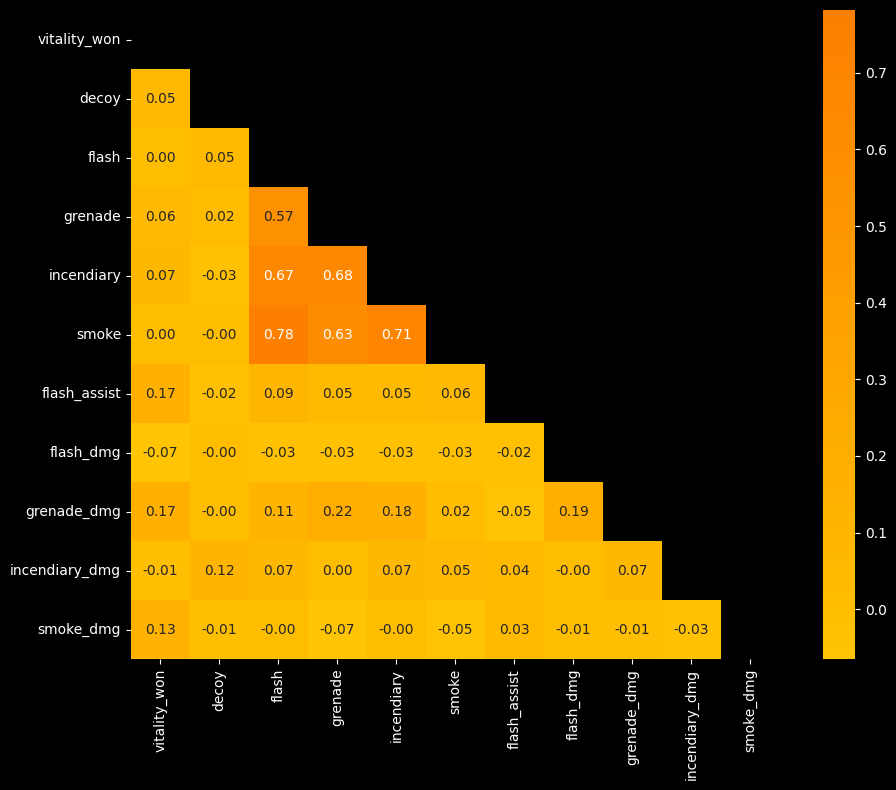

In [ ]:
plot_util_correlation(vitality_util_plot, "vitality", threshold = 0.0)

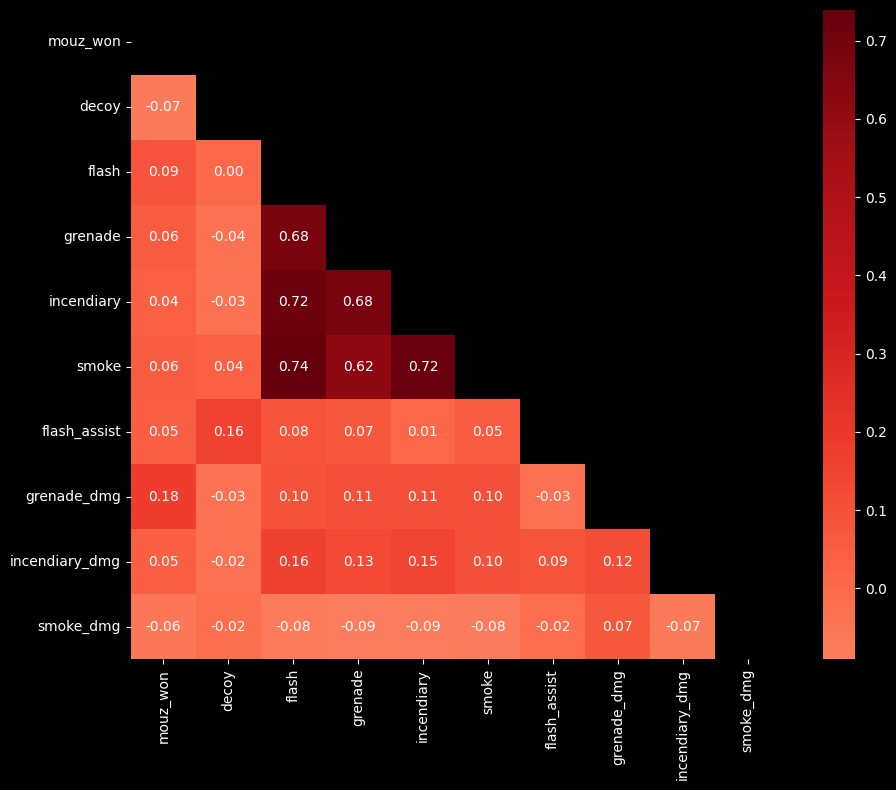

In [ ]:
plot_util_correlation(mouz_util_plot, "mouz", threshold = 0.0)

Since the major focus of the project was to see utility's influce on round outcome, we landed on point biserial, which is good for binary dataset (round win or loss). Also in using barchart rather than a correlation matrix, it is easier to see each utility's effect on the round outcome.

In [ ]:
from scipy.stats import pointbiserialr
def plot_pointbiserial(df, team_name):
  numeric_cols = df.select_dtypes(include=[np.number]).columns.drop([f"{team_name}_won"])
  corr = []

  for col in numeric_cols:
    r,p = pointbiserialr(df[f"{team_name}_won"], df[col])
    corr.append({"feature": col, "correlation": round(r,3), "p-value": p})

  corr_df = pd.DataFrame(corr).sort_values(by="correlation", ascending=False)

  color = "Reds" if team_name == "mouz" else "Wistia"

  plt.figure(figsize=(10, 8))
  ax = sns.barplot(data = corr_df,
              x="correlation",
              y = "feature",
              palette = color,
              hue = "feature",
              legend = False
              )
  for container in ax.containers:
    ax.bar_label(container)

  plt.title(f"Point-Biserial Correlation - {team_name} on round-win")
  plt.xlabel("Correlation")
  plt.ylabel("Feature")
  plt.show()

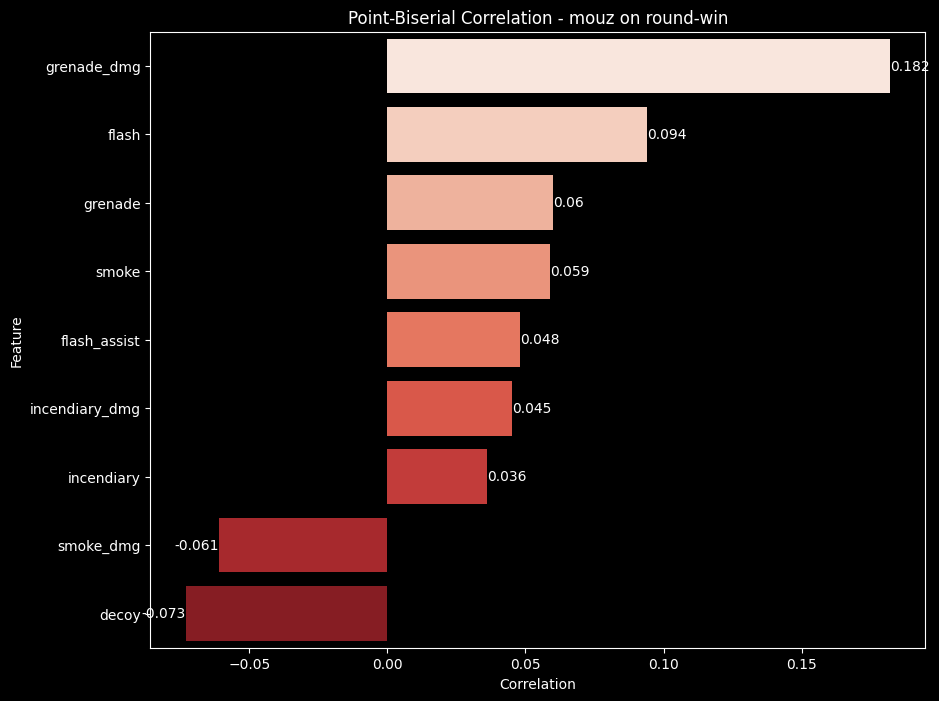

In [ ]:
plot_pointbiserial(mouz_util_plot, "mouz")

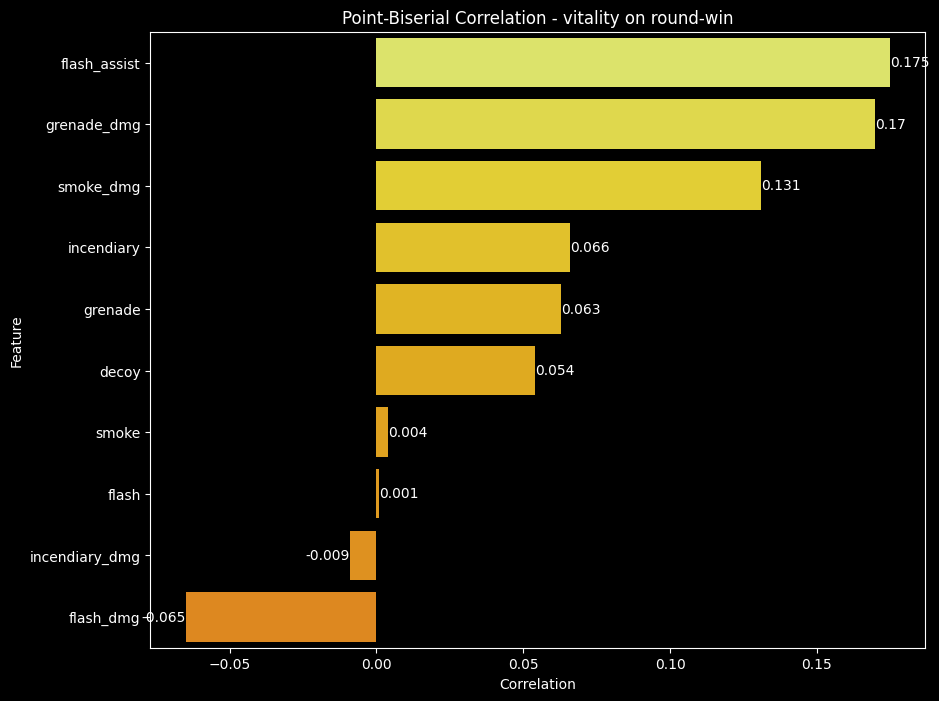

In [ ]:
plot_pointbiserial(vitality_util_plot, "vitality")